# MET-AI Interventions — Deep Analysis of the Final Dataset (All Conditions)

This is the **self-contained deep-analysis notebook for the merged final dataset** in
`data_analysis/results/data/final_data/`. That folder combines both data-collection waves of the
study into one per-condition export (built by `data_analysis/results/build_final_data.py` and
flattened to CSV by `data_analysis/results/export_condition_csvs.py`):

| Condition | Intervention | Wave |
|---|---|---|
| `ai` | Plain AI chat (baseline) | 1 (Jul 2026) + 5 participants in wave 2 (Aug 2026) |
| `ai-reliability` | Per-task AI reliability cards with evaluation strategies | 1 (Jul 2026) |
| `alternatives` | AI answers with multiple alternative replies | 2 (Aug 2026) |
| `pause-points` | AI answers step by step with pause points | 2 (Aug 2026) |
| `reflection-task` | Post-task reflection pages after every main task | 2 (Aug 2026) |

All conditions share the same 12 planning/organizing problems (3 scenarios × 4 problems), the
same pre/post questionnaires, and the same standardized scales (SUS, UEQ-S, NASA-TLX, NFC, Trust).

## How to use this notebook

1. On a fresh environment, install the dependencies once:
   `pip install pandas numpy scipy statsmodels matplotlib`
2. Review the configuration in **Part 1, Section 2**.
3. Run all cells of **Part 1** top to bottom (loading, integrity audit, scoring, exclusions).
4. Run any module of **Part 2**; each module is self-contained once Part 1 has completed.
5. Run the export module at the end to write prepared tables to `notebook_analysis_output/`.

The confirmatory outcome families follow the two per-wave analysis notebooks
(`deep_analysis/real_paul`, `deep_analysis/real_interventions`): metacognitive accuracy of the
global self-estimate, confidence discrimination, prompts per completed task, and actual task
score. Everything else is exploratory. **Because the baseline condition was collected almost
entirely in wave 1 and the three chat-structure interventions in wave 2, every cross-wave
comparison carries a cohort confound; module O quantifies it and the summary flags it.**

## Part 1 — Data preparation

### 1. Imports and study constants

The canonical answer key is `src/customizations/questions/correct_answers.py` — the exact module the
backend imported at runtime to score participants (`interface-backend/app.py`,
`evaluate_answers`). Section 4 verifies that recomputing every item from this key reproduces the
backend's stored `answerResults` bit for bit, and documents where the convenience CSVs disagree.

In [1]:
from __future__ import annotations

import ast
import json
import math
import re
import textwrap
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

# Canonical correct answers in authored task order (src/customizations/questions/correct_answers.py).
CORRECT_ANSWERS = [
    "Neither of the two statements is correct.",  # ypc_02 (D)
    "Only statement 2 is correct.",               # ypc_03 (B)
    "Only statement 1 is correct.",               # ypc_05 (A)
    "Only statement 1 is correct.",               # ypc_06 (A)
    "Neither of the two statements is correct.",  # car_racing_01 (D)
    "Both statements are correct.",               # car_racing_02 (C)
    "Only statement 2 is correct.",               # car_racing_03 (B)
    "Only statement 1 is correct.",               # car_racing_05 (A)
    "Only statement 2 is correct.",               # graduation_party_01 (B)
    "Only statement 1 is correct.",               # graduation_party_05 (A)
    "Neither of the two statements is correct.",  # graduation_party_06 (D)
    "Only statement 2 is correct.",               # graduation_party_07 (B)
]

TASK_NAMES = [
    "ypc_02", "ypc_03", "ypc_05", "ypc_06",
    "car_racing_01", "car_racing_02", "car_racing_03", "car_racing_05",
    "graduation_party_01", "graduation_party_05",
    "graduation_party_06", "graduation_party_07",
]

SCENARIO_OF = {
    "ypc": "Young Professionals Consulting",
    "car_racing": "Incentive Car Racing",
    "graduation_party": "Graduation Party",
}

CONDITIONS = ["ai", "ai-reliability", "alternatives", "pause-points", "reflection-task"]
BASELINE = "ai"
CONDITION_LABELS = {
    "ai": "AI (baseline)",
    "ai-reliability": "Reliability cards",
    "alternatives": "Alternatives",
    "pause-points": "Pause points",
    "reflection-task": "Reflection task",
}
TICK_LABELS = {  # two-line variants that fit narrow panels
    "ai": "AI\n(baseline)",
    "ai-reliability": "Reliability\ncards",
    "alternatives": "Alterna-\ntives",
    "pause-points": "Pause\npoints",
    "reflection-task": "Reflection\ntask",
}
# Colorblind-safe categorical palette (validated: adjacent-pair CVD dE >= 8, normal-vision dE >= 15).
CONDITION_COLORS = {
    "ai": "#2a78d6",
    "ai-reliability": "#eb6834",
    "alternatives": "#1baf7a",
    "pause-points": "#eda100",
    "reflection-task": "#e87ba4",
}

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c8c8c4",
    "axes.labelcolor": "#33322e",
    "axes.titlecolor": "#33322e",
    "axes.grid": True,
    "grid.color": "#eceae6",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "xtick.color": "#6f6d66",
    "ytick.color": "#6f6d66",
    "text.color": "#33322e",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def style_ax(ax: plt.Axes) -> None:
    ax.grid(axis="x", visible=False)
    ax.tick_params(length=0)

### 2. Configuration

In [2]:
# Paths are relative to this notebook's folder (data_analysis/deep_analysis/final_data/).
DATA_DIR = Path("../../results/data/final_data")
REPEATED_CSV = DATA_DIR / "repeated.csv"
MANUAL_EXCLUSION_FILE = Path("../../exclusions/excluded_participant_ids_paul.txt")
OUTPUT_DIR = Path("notebook_analysis_output")

# ------------------------------- Exclusions -------------------------------
# Rule-based exclusion flags are always computed; this switch controls whether
# they are applied to the analysis sample used by Part 2.
APPLY_EXCLUSIONS = True
MINIMUM_COMPLETION_MINUTES = 10.0
EXPECTED_MAIN_TASKS = 12
MAX_ATTENTION_FAILURES = 1  # more failures than this -> excluded

# Safety net: if the loaded data ever contains the same participant twice,
# keep only the earliest run (later runs are practice-contaminated). The
# committed final_data is already deduplicated this way, so this normally
# excludes nobody.
EXCLUDE_REPEATED_LATER_RUNS = True

# The wave-1 analysis kept a manual ID list ("less than 30%", provenance not
# fully documented). It is loaded and flagged, but not applied by default;
# flip this on for a sensitivity analysis.
APPLY_MANUAL_EXCLUSIONS = False

# ------------------------------- Statistics -------------------------------
ALPHA = 0.05
CONFIDENCE_LEVEL = 0.95
# "directional" follows the per-wave notebooks' preregistered one-sided tests;
# "two-sided" is the conservative option for this merged, cross-wave dataset.
CONFIRMATORY_P_VALUE = "directional"

for name, cond in [("MINIMUM_COMPLETION_MINUTES", MINIMUM_COMPLETION_MINUTES >= 0),
                   ("ALPHA", 0 < ALPHA < 1),
                   ("CONFIDENCE_LEVEL", 0 < CONFIDENCE_LEVEL < 1),
                   ("CONFIRMATORY_P_VALUE", CONFIRMATORY_P_VALUE in {"directional", "two-sided"})]:
    if not cond:
        raise ValueError(f"invalid configuration: {name}")

print("Notebook working directory:", Path.cwd())
print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Notebook working directory: /home/user/MET_AI_Interventions/data_analysis/deep_analysis/final_data
Data directory: /home/user/MET_AI_Interventions/data_analysis/results/data/final_data
Output directory: /home/user/MET_AI_Interventions/data_analysis/deep_analysis/final_data/notebook_analysis_output


### 3. Parsing helpers

In [3]:
def norm(value: Any) -> str:
    return re.sub(r"\s+", " ", str(value or "")).strip().casefold()


def number(value: Any) -> float:
    try:
        v = float(value)
    except (TypeError, ValueError):
        return math.nan
    return v


def parse_time(value: Any) -> float:
    """Epoch seconds from ms timestamps or ISO strings; NaN when unparseable."""
    if value is None:
        return math.nan
    if isinstance(value, (int, float)):
        value = float(value)
        return value / 1000 if value > 10_000_000_000 else value
    try:
        return datetime.fromisoformat(str(value).replace("Z", "+00:00")).timestamp()
    except ValueError:
        return math.nan


def task_items(record: dict[str, Any]) -> list[tuple[int, dict[str, Any]]]:
    result = []
    for key, task in (record.get("tasks") or {}).items():
        try:
            result.append((int(key), task if isinstance(task, dict) else {}))
        except (TypeError, ValueError):
            continue
    return sorted(result)


def responses(task: dict[str, Any]) -> list[dict[str, Any]]:
    resp = task.get("responses") or {}
    keyed = sorted(resp.items(), key=lambda kv: number(kv[0].split(".")[-1]))
    return [r for _, r in keyed if isinstance(r, dict)]


def find_task(record: dict[str, Any], pattern: str) -> tuple[int | None, dict[str, Any] | None]:
    rx = re.compile(pattern, re.I)
    for task_id, task in task_items(record):
        if any(rx.search(str(r.get("question", ""))) for r in responses(task)):
            return task_id, task
    return None, None


def answer_in_task(task: dict[str, Any] | None, pattern: str) -> Any:
    if not task:
        return None
    rx = re.compile(pattern, re.I)
    for r in responses(task):
        if rx.search(str(r.get("question", ""))):
            return r.get("answer")
    return None


def find_response(record: dict[str, Any], pattern: str) -> Any:
    rx = re.compile(pattern, re.I)
    for _, task in task_items(record):
        for r in responses(task):
            if rx.search(str(r.get("question", ""))):
                return r.get("answer")
    return None


def main_task_ids(record: dict[str, Any]) -> list[int]:
    """Authored IDs of the 12 scored problems.

    Primary source: the keys of the backend's stored ``answerResults`` (what was
    actually scored at save time). Fallbacks reproduce the backend heuristics:
    tasks titled "Scenario: ..." (wave 2), else tasks carrying a confidence item
    (wave 1, which stored no titles).
    """
    results = record.get("answerResults") or {}
    ids = sorted({int(k.split(".")[0]) for k in results if re.fullmatch(r"\d+\.\d+", k)})
    if len(ids) == EXPECTED_MAIN_TASKS:
        return ids
    titled = sorted(tid for tid, t in task_items(record)
                    if str(t.get("title") or "").startswith("Scenario:"))
    if titled:
        return titled[-EXPECTED_MAIN_TASKS:]
    with_conf = []
    for tid, task in task_items(record):
        conf = (task.get("responses") or {}).get(f"{tid}.2", {})
        if isinstance(conf, dict) and "confident" in norm(conf.get("question")):
            with_conf.append(tid)
    return sorted(with_conf)[-EXPECTED_MAIN_TASKS:]


def clean_demographic_answer(value: Any) -> str:
    """Render answers like "['Woman']" as plain text."""
    text = str(value or "").strip()
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, (list, tuple)):
                return ", ".join(str(v).strip() for v in parsed)
        except (ValueError, SyntaxError):
            pass
    return text


def assistant_text(message: dict[str, Any]) -> str:
    """Assistant message text; wave 2 stores it under choices[i].message.content."""
    if message.get("content"):
        return str(message["content"])
    parts = []
    for choice in message.get("choices") or []:
        if isinstance(choice, dict):
            inner = choice.get("message") or {}
            if isinstance(inner, dict) and inner.get("content"):
                parts.append(str(inner["content"]))
    return "\n".join(parts)

### 4. Load the final dataset and audit its integrity

Three independent representations exist for every condition: the JSON export (raw records —
the analysis source of truth), the backend's stored per-item scoring (`answerResults`), and the
flattened convenience CSV. This section loads the JSONs and cross-checks all three.

In [4]:
FINAL_FILES = {c: DATA_DIR / f"{c.replace('-', '_')}.json" for c in CONDITIONS}
missing = [str(p) for p in FINAL_FILES.values() if not p.exists()]
if missing:
    raise FileNotFoundError(f"final_data files not found: {missing}")

records: list[dict[str, Any]] = []
for condition, path in FINAL_FILES.items():
    loaded = json.loads(path.read_text(encoding="utf-8-sig"))["participants"]
    for rec in loaded:
        if rec.get("condition") != condition:
            raise ValueError(f"{path.name}: record {rec.get('participantId')} has "
                             f"condition {rec.get('condition')!r}")
    records.extend(loaded)
    print(f"{path.name}: {len(loaded)} participants")
print(f"TOTAL: {len(records)} participant records")

ai.json: 189 participants


ai_reliability.json: 184 participants


alternatives.json: 183 participants


pause_points.json: 184 participants


reflection_task.json: 185 participants
TOTAL: 925 participant records


In [5]:
# Wave assignment. Wave-1 exports (Jul 2026) predate task titles; wave-2 exports
# (Aug 2026) store a title on every page. The saved-at timeline in module B
# confirms the split.
for rec in records:
    rec["_wave"] = 2 if any(t.get("title") for _, t in task_items(rec)) else 1
    rec["_saved_ts"] = parse_time(rec.get("savedAt"))

wave_table = (
    pd.DataFrame([{ "condition": r["condition"], "wave": r["_wave"]} for r in records])
    .value_counts().unstack(fill_value=0).reindex(CONDITIONS).sort_index(axis=1)
)
wave_table.columns = [f"wave {c}" for c in wave_table.columns]
display(wave_table)

,wave 1,wave 2
condition,,
ai,184,5
ai-reliability,184,0
alternatives,0,183
pause-points,0,184
reflection-task,0,185


In [6]:
# Integrity check 1 - recomputing every item from the canonical answer key must
# reproduce the backend's stored answerResults exactly.
item_checks = item_mismatches = 0
for rec in records:
    ids = main_task_ids(rec)
    if len(ids) != EXPECTED_MAIN_TASKS:
        raise AssertionError(f"{rec['participantId']}: found {len(ids)} main tasks")
    stored = rec.get("answerResults") or {}
    for tid, expected in zip(ids, CORRECT_ANSWERS):
        answer = ((rec["tasks"].get(str(tid), {}).get("responses") or {})
                  .get(f"{tid}.1", {}) or {}).get("answer")
        recomputed = norm(answer) == norm(expected)
        if f"{tid}.1" in stored:
            item_checks += 1
            item_mismatches += recomputed != bool(stored[f"{tid}.1"])
print(f"canonical key vs backend answerResults: {item_mismatches} mismatches "
      f"across {item_checks} scored items")
if item_mismatches:
    raise AssertionError("canonical answer key does not reproduce backend scoring")

canonical key vs backend answerResults: 0 mismatches across 11100 scored items


In [7]:
# Integrity check 2 - the convenience CSVs. Since Aug 2026, export_condition_csvs.py
# takes correctness from each record's own answerResults (no hard-coded key) and
# asserts n_correct == correctAnswers per row. (The original exporter scored against
# a key that was wrong on 8/12 items; those CSVs were regenerated.) Verify row
# counts and per-question agreement with answerResults here; the notebook itself
# still derives every metric from the JSON records.
csv_frames = {}
csv_item_checks = csv_item_mismatches = 0
for condition in CONDITIONS:
    csv_path = DATA_DIR / f"{condition.replace('-', '_')}.csv"
    frame = pd.read_csv(csv_path, dtype={"participantId": str})
    csv_frames[condition] = frame
    by_pid = frame.set_index("participantId")
    n_json = 0
    for rec in records:
        if rec["condition"] != condition:
            continue
        n_json += 1
        stored = rec.get("answerResults") or {}
        ids = main_task_ids(rec)
        row = by_pid.loc[str(rec["participantId"])]
        for name, tid in zip(TASK_NAMES, ids):
            if f"{tid}.1" in stored:
                csv_item_checks += 1
                csv_item_mismatches += int(row[f"{name}_correct"]) != int(bool(stored[f"{tid}.1"]))
    status = "OK" if len(frame) == n_json else "MISMATCH"
    print(f"{csv_path.name}: {len(frame)} rows vs {n_json} JSON records -> {status}")
print(f"CSV *_correct vs backend answerResults: {csv_item_mismatches} mismatches "
      f"across {csv_item_checks} items")
if csv_item_mismatches:
    raise AssertionError("CSV correctness columns disagree with backend scoring - "
                         "regenerate them with export_condition_csvs.py")

ai.csv: 189 rows vs 189 JSON records -> OK


ai_reliability.csv: 184 rows vs 184 JSON records -> OK
alternatives.csv: 183 rows vs 183 JSON records -> OK


pause_points.csv: 184 rows vs 184 JSON records -> OK


reflection_task.csv: 185 rows vs 185 JSON records -> OK
CSV *_correct vs backend answerResults: 0 mismatches across 11100 items


In [8]:
# Integrity check 3 - repeated participation. Some participants took part in
# two conditions across the waves. The final_data export keeps exactly one
# record per participant - the EARLIEST run (verified against the raw wave
# exports under results/data/real_interventions and real_paul); repeated.csv
# documents whose later run was dropped. The dedup below is therefore a
# safety net that only engages if the export ever regains duplicates.
by_pid: dict[str, list[dict]] = {}
for rec in records:
    by_pid.setdefault(str(rec["participantId"]), []).append(rec)

duplicate_pids = {pid: [r["condition"] for r in rs]
                  for pid, rs in by_pid.items() if len(rs) > 1}
print(f"duplicate participant IDs inside final_data: {len(duplicate_pids)}"
      + (" (unexpected - only the earliest run will be analyzed)" if duplicate_pids else ""))

repeated_ids: set[str] = set()
if REPEATED_CSV.exists():
    repeated_ids = set(pd.read_csv(REPEATED_CSV)["participant"].astype(str))
    present = repeated_ids & set(by_pid)
    print(f"repeated.csv: {len(repeated_ids)} participants with a dropped second run; "
          f"{len(present)} of them appear (once) in final_data")

for rs in by_pid.values():
    order = sorted(rs, key=lambda r: (r["_saved_ts"] if math.isfinite(r["_saved_ts"]) else math.inf))
    for run_index, rec in enumerate(order):
        rec["_run_index"] = run_index          # 0 = earliest participation
        rec["_n_runs"] = len(order)

pd.DataFrame({"participants": {
    "unique IDs in final_data": len(by_pid),
    "duplicate records (safety net)": len(duplicate_pids),
    "listed in repeated.csv (later run dropped)": len(repeated_ids),
}})

duplicate participant IDs inside final_data: 0
repeated.csv: 38 participants with a dropped second run; 38 of them appear (once) in final_data


,participants
unique IDs in final_data,925
duplicate records (safety net),0
listed in repeated.csv (later run dropped),38


### 5. Questionnaire scoring

Scale scoring mirrors the per-wave analysis notebooks:

* **SUS** — 10 items (the embedded attention item is dropped), alternating `v−1` / `5−v`, sum × 2.5 → 0–100.
* **UEQ-S** — 8 items shifted by −4 → −3…+3; pragmatic = items 1–4, hedonic = items 5–8.
* **NASA-TLX (raw)** — mean of 6 subscales (0–20). The performance item asks how *successful*
  participants were, so it is reversed (`21−v`) so that higher always means more workload.
  `tlx_raw_mean` (no reversal) is kept for cross-checks against the dashboard/CSVs.
* **NFC** — 6 items (1–5), items 3 and 4 reversed.
* **Trust** — 8 items (1–5), item 6 ("wary") reversed.

In [9]:
def scale_values(record: dict[str, Any]) -> dict[str, Any]:
    sus_id, sus_task = find_task(record, r"like to use this system frequently")
    sus = math.nan
    sus_items: list[float] = []
    if sus_task:
        sus_items = [number(r.get("answer")) for r in responses(sus_task)
                     if "reading this" not in norm(r.get("question"))]
        if len(sus_items) == 10 and all(math.isfinite(v) for v in sus_items):
            sus = sum((v - 1) if i % 2 == 0 else (5 - v) for i, v in enumerate(sus_items)) * 2.5

    # UEQ-S items carry no question text; the task immediately precedes SUS in every layout.
    task_map = dict(task_items(record))
    ueq_items: list[float] = []
    if sus_id is not None and sus_id - 1 in task_map:
        raw = [number(r.get("answer")) for r in responses(task_map[sus_id - 1])]
        if len(raw) == 8 and all(math.isfinite(v) for v in raw):
            ueq_items = [v - 4 for v in raw]

    _, nfc_task = find_task(record, r"prefer complex to simple problems")
    nfc_items = [number(r.get("answer")) for r in responses(nfc_task or {})]
    nfc_scored = list(nfc_items)
    if len(nfc_scored) == 6:
        nfc_scored[2], nfc_scored[3] = 6 - nfc_scored[2], 6 - nfc_scored[3]
    else:
        nfc_scored = []

    _, tlx_task = find_task(record, r"mentally demanding")
    tlx_items = [number(r.get("answer")) for r in responses(tlx_task or {})]
    tlx_scored = list(tlx_items)
    if len(tlx_scored) == 6 and math.isfinite(tlx_scored[3]):
        tlx_scored[3] = 21 - tlx_scored[3]

    _, trust_task = find_task(record, r"confident in the AI system")
    trust_items = [number(r.get("answer")) for r in responses(trust_task or {})]
    trust_scored = list(trust_items)
    if len(trust_scored) >= 6 and math.isfinite(trust_scored[5]):
        trust_scored[5] = 6 - trust_scored[5]

    def mean_or_nan(values: Iterable[float]) -> float:
        vals = [v for v in values if math.isfinite(v)]
        return sum(vals) / len(vals) if vals else math.nan

    return {
        "sus_score": sus,
        "ueq_overall": mean_or_nan(ueq_items),
        "ueq_pragmatic": mean_or_nan(ueq_items[:4]),
        "ueq_hedonic": mean_or_nan(ueq_items[4:]),
        "tlx_mean": mean_or_nan(tlx_scored),
        "tlx_raw_mean": mean_or_nan(tlx_items),
        "nfc_mean": mean_or_nan(nfc_scored),
        "trust_mean": mean_or_nan(trust_scored),
        "_sus_items": sus_items, "_ueq_items": ueq_items, "_nfc_items": nfc_scored,
        "_tlx_items": tlx_scored, "_trust_items": trust_scored,
    }


def attention_checks(record: dict[str, Any]) -> tuple[int, int]:
    """(passed, found) across the four embedded checks."""
    checks: list[bool] = []
    for _, task in task_items(record):
        for r in responses(task):
            q, a = norm(r.get("question")), r.get("answer")
            if "what type of tasks will you be working on" in q:
                checks.append(norm(a) == "planning and organizing")
            elif "second tab" in q and "which letter" in q:
                checks.append(str(a).strip().upper() == "C")
            elif "reading this" in q and "enter the number 5" in q:
                checks.append(str(a).strip() == "5")
            elif "reading this" in q and "highest possible value" in q:
                checks.append(number(a) == 5)
    return sum(checks), len(checks)

### 6. Behavioral measures: chat, interaction log, and timing

In [10]:
AI_USE_SCORES = {
    "several times a day": 7, "about once a day": 6, "a few times a week": 5,
    "about once a week": 4, "a few times a month": 3, "less than once a month": 2, "never": 1,
}


def chat_measures(record: dict[str, Any], main_ids: list[int]) -> dict[str, Any]:
    main_set = set(main_ids)
    user_msgs, asst_msgs = [], []
    for msg in record.get("messages") or []:
        if not isinstance(msg, dict):
            continue  # a handful of null entries exist in the alternatives export
        if msg.get("role") == "user":
            user_msgs.append(msg)
        elif msg.get("role") == "assistant":
            asst_msgs.append(msg)

    main_prompts = [m for m in user_msgs if number(m.get("task")) in main_set]
    prompt_words = [len(str(m.get("content", "")).split()) for m in main_prompts]
    with_flag = [m for m in main_prompts if m.get("hasTaskQuestion") is not None]
    pasted = [m for m in with_flag if m.get("hasTaskQuestion")]

    output_tokens = reasoning_tokens = 0
    for msg in asst_msgs:
        usage = msg.get("usage") or {}
        output_tokens += usage.get("output_tokens") or 0
        reasoning_tokens += (usage.get("output_tokens_details") or {}).get("reasoning_tokens") or 0

    tasks_prompted = {int(number(m.get("task"))) for m in main_prompts}
    return {
        "total_user_messages": len(user_msgs),
        "total_assistant_messages": len(asst_msgs),
        "main_prompts": len(main_prompts),
        "main_tasks_prompted": len(tasks_prompted),
        "mean_prompt_words": float(np.mean(prompt_words)) if prompt_words else math.nan,
        "pasted_task_share": len(pasted) / len(with_flag) if with_flag else math.nan,
        "assistant_output_tokens": output_tokens,
        "assistant_reasoning_tokens": reasoning_tokens,
        "_main_prompt_msgs": main_prompts,
    }


def event_measures(record: dict[str, Any], main_ids: list[int]) -> dict[str, Any]:
    main_set = set(main_ids)
    counts = {"chat_resets": 0, "gate_tests": 0, "gate_matched": 0,
              "similarity_tests": 0, "cards_hidden": 0, "cards_unhidden": 0}
    card_tasks: set[int] = set()
    gate_coverage: list[float] = []
    for event in record.get("interactionLog") or []:
        if not isinstance(event, dict):
            continue
        etype = event.get("type")
        tid = number(event.get("taskId"))
        if etype == "chat_reset":
            counts["chat_resets"] += 1
        elif etype == "intervention_gate_test":
            counts["gate_tests"] += 1
            counts["gate_matched"] += bool(event.get("matched"))
            cov = number(event.get("coverage"))
            if math.isfinite(cov):
                gate_coverage.append(cov)
        elif etype == "reliability_similarity_test":
            counts["similarity_tests"] += 1
        elif etype == "reliability_card_presented" and tid in main_set:
            card_tasks.add(int(tid))
        elif etype == "reliability_card_hidden":
            counts["cards_hidden"] += 1
        elif etype == "reliability_card_unhidden":
            counts["cards_unhidden"] += 1
    # Wave-1 fallback: a persisted per-task timestamp marks a presented card.
    for tid, task in task_items(record):
        if tid in main_set and task.get("reliabilityShownAt") is not None:
            card_tasks.add(tid)
    return {
        **counts,
        "reliability_cards_presented": len(card_tasks),
        "gate_max_coverage": max(gate_coverage) if gate_coverage else math.nan,
    }


def reflection_measures(record: dict[str, Any]) -> dict[str, Any]:
    """Word counts on the 'Pause and reflect' pages (reflection-task condition only)."""
    pages = words = 0
    for _, task in task_items(record):
        if str(task.get("title") or "") != "Pause and reflect":
            continue
        answered = [str(r.get("answer") or "") for r in responses(task)]
        if any(a.strip() for a in answered):
            pages += 1
        words += sum(len(a.split()) for a in answered)
    return {"reflection_pages_answered": pages, "reflection_words": words}


def timing_measures(record: dict[str, Any], main_ids: list[int]) -> dict[str, Any]:
    """Completion time and per-main-task dwell time from client page-entry stamps."""
    stamped = [(tid, parse_time(task.get("ts"))) for tid, task in task_items(record)]
    stamped = [(tid, ts) for tid, ts in stamped if math.isfinite(ts)]
    stamped.sort(key=lambda pair: pair[1])
    times = [ts for _, ts in stamped]

    if len(times) >= 2:
        completion_seconds = times[-1] - times[0]
        source = "client task timestamps"
    else:
        saved = record["_saved_ts"]
        completion_seconds = (saved - times[0]) if times and math.isfinite(saved) else math.nan
        source = "savedAt fallback"

    dwell: dict[int, float] = {}
    for (tid, ts), (_, next_ts) in zip(stamped, stamped[1:]):
        if tid in set(main_ids):
            dwell[tid] = next_ts - ts
    return {
        "completion_seconds": completion_seconds,
        "completion_time_source": source,
        "_dwell_seconds": dwell,
    }

### 7. Score every participant

One row per participant (`participants` frame), one row per participant × problem
(`task_level` frame), and one row per main-task prompt (`prompts` frame).

In [11]:
participant_rows, task_rows, prompt_rows = [], [], []
scale_items_store = []  # scored per-item values, for internal-consistency estimates (module L)

for rec in records:
    pid = str(rec["participantId"])
    condition = rec["condition"]
    ids = main_task_ids(rec)
    scales = scale_values(rec)
    chat = chat_measures(rec, ids)
    events = event_measures(rec, ids)
    timing = timing_measures(rec, ids)
    scale_items_store.append({
        "participant_id": pid, "run_index": rec["_run_index"],
        "sus": ([(v - 1) if i % 2 == 0 else (5 - v) for i, v in enumerate(scales["_sus_items"])]
                if len(scales["_sus_items"]) == 10 else []),
        "ueq": scales["_ueq_items"], "nfc": scales["_nfc_items"],
        "tlx": scales["_tlx_items"], "trust": scales["_trust_items"],
    })

    correct_flags, confidences = [], []
    for ordinal, (tid, expected, name) in enumerate(zip(ids, CORRECT_ANSWERS, TASK_NAMES), 1):
        task = rec["tasks"].get(str(tid), {})
        resp = task.get("responses") or {}
        answer = (resp.get(f"{tid}.1") or {}).get("answer")
        confidence = number((resp.get(f"{tid}.2") or {}).get("answer"))
        answered = answer is not None
        correct = answered and norm(answer) == norm(expected)
        correct_flags.append(correct if answered else math.nan)
        confidences.append(confidence)
        task_rows.append({
            "participant_id": pid, "condition": condition, "wave": rec["_wave"],
            "run_index": rec["_run_index"],
            "task_id": tid, "task_name": name,
            "scenario": SCENARIO_OF[name.rsplit("_", 1)[0]],
            "authored_order": ordinal, "display_index": task.get("displayIndex"),
            "answer": answer, "correct_answer": expected,
            "correct": float(correct) if answered else math.nan,
            "confidence": confidence,
            "dwell_seconds": timing["_dwell_seconds"].get(tid, math.nan),
            "prompts_on_task": sum(1 for m in chat["_main_prompt_msgs"]
                                   if number(m.get("task")) == tid),
        })

    for msg in chat["_main_prompt_msgs"]:
        prompt_rows.append({
            "participant_id": pid, "condition": condition, "wave": rec["_wave"],
            "task_id": int(number(msg.get("task"))),
            "words": len(str(msg.get("content", "")).split()),
            "has_task_question": msg.get("hasTaskQuestion"),
            "ts": parse_time(msg.get("ts")),
        })

    answered_flags = [f for f in correct_flags if not (isinstance(f, float) and math.isnan(f))]
    actual_score = int(sum(answered_flags))
    completed_tasks = len(answered_flags)
    score_percent = actual_score / EXPECTED_MAIN_TASKS * 100

    finite_conf = [c for c in confidences if math.isfinite(c)]
    conf_correct = [c for c, ok in zip(confidences, correct_flags)
                    if ok is True and math.isfinite(c)]
    conf_incorrect = [c for c, ok in zip(confidences, correct_flags)
                      if ok is False and math.isfinite(c)]
    mean_conf = float(np.mean(finite_conf)) if finite_conf else math.nan
    mean_conf_correct = float(np.mean(conf_correct)) if conf_correct else math.nan
    mean_conf_incorrect = float(np.mean(conf_incorrect)) if conf_incorrect else math.nan
    discrimination = (mean_conf_correct - mean_conf_incorrect
                      if conf_correct and conf_incorrect else math.nan)

    # Pre- and post-questionnaire global estimates, located by their signature items.
    _, pre_task = find_task(rec, r"do you think you would solve correctly")
    _, post_task = find_task(rec, r"do you think you have solved correctly")
    pre_with = number(answer_in_task(pre_task, r"^Using the AI"))
    pre_without = number(answer_in_task(pre_task, r"^Without AI use"))
    pre_ai_alone = number(answer_in_task(pre_task, r"^On its own"))
    pre_self_pct = number(answer_in_task(pre_task, r"^Compared to other participants"))
    pre_ai_pct = number(answer_in_task(pre_task, r"^Compared to other AI systems"))
    post_with = number(answer_in_task(post_task, r"^Using the AI"))
    post_without = number(answer_in_task(post_task, r"^Without AI use"))
    post_ai_alone = number(answer_in_task(post_task, r"^On its own"))
    post_self_pct = number(answer_in_task(post_task, r"^Compared to other participants"))
    post_ai_pct = number(answer_in_task(post_task, r"^Compared to other AI systems"))

    attention_passed, attention_found = attention_checks(rec)
    ai_use_answer = find_response(rec, r"how often do you use AI assistants")

    row = {
        "participant_id": pid,
        "condition": condition,
        "condition_label": CONDITION_LABELS[condition],
        "wave": rec["_wave"],
        "run_index": rec["_run_index"],
        "n_runs": rec["_n_runs"],
        "saved_at": rec.get("savedAt"),
        "saved_ts": rec["_saved_ts"],
        # -- performance and item-level calibration --
        "actual_score": actual_score,
        "score_percent": score_percent,
        "completed_main_tasks": completed_tasks,
        "mean_confidence": mean_conf,
        "mean_conf_correct": mean_conf_correct,
        "mean_conf_incorrect": mean_conf_incorrect,
        "confidence_discrimination": discrimination,
        "signed_confidence_gap": mean_conf - score_percent,
        "absolute_confidence_gap": abs(mean_conf - score_percent),
        # -- global self-estimates --
        "pre_with_ai": pre_with, "pre_without_ai": pre_without, "pre_ai_alone": pre_ai_alone,
        "pre_self_percentile": pre_self_pct, "pre_ai_percentile": pre_ai_pct,
        "post_with_ai": post_with, "post_without_ai": post_without, "post_ai_alone": post_ai_alone,
        "post_self_percentile": post_self_pct, "post_ai_percentile": post_ai_pct,
        "signed_estimation_error": post_with - actual_score,
        "absolute_estimation_error": abs(post_with - actual_score),
        "estimate_shift_with_ai": post_with - pre_with,
        "estimate_shift_without_ai": post_without - pre_without,
        "estimate_shift_ai_alone": post_ai_alone - pre_ai_alone,
        # -- chat behavior --
        "total_prompts": chat["main_prompts"],
        "prompts_per_task": chat["main_prompts"] / completed_tasks if completed_tasks else math.nan,
        "main_tasks_prompted": chat["main_tasks_prompted"],
        "mean_prompt_words": chat["mean_prompt_words"],
        "pasted_task_share": chat["pasted_task_share"],
        "total_user_messages": chat["total_user_messages"],
        "total_assistant_messages": chat["total_assistant_messages"],
        "assistant_output_tokens": chat["assistant_output_tokens"],
        "assistant_reasoning_tokens": chat["assistant_reasoning_tokens"],
        # -- interaction log --
        "chat_resets": events["chat_resets"],
        "gate_tests": events["gate_tests"],
        "gate_matched": events["gate_matched"],
        "gate_max_coverage": events["gate_max_coverage"],
        "reliability_cards_presented": events["reliability_cards_presented"],
        "similarity_tests": events["similarity_tests"],
        "cards_hidden": events["cards_hidden"],
        **reflection_measures(rec),
        # -- timing --
        "completion_seconds": timing["completion_seconds"],
        "completion_minutes": timing["completion_seconds"] / 60,
        "completion_time_source": timing["completion_time_source"],
        # -- scales --
        **{k: v for k, v in scales.items() if not k.startswith("_")},
        # -- attention and demographics --
        "attention_passed": attention_passed,
        "attention_found": attention_found,
        "attention_failed": attention_found - attention_passed,
        "age": number(find_response(rec, r"what is your age")),
        "gender": clean_demographic_answer(find_response(rec, r"what is your gender")),
        "education": clean_demographic_answer(
            find_response(rec, r"highest level of school|highest degree")),
        "fluency": clean_demographic_answer(find_response(rec, r"fluency in the English language")),
        "ai_use_label": clean_demographic_answer(ai_use_answer),
        "ai_use_frequency": AI_USE_SCORES.get(norm(ai_use_answer), math.nan),
        # -- shared intervention-experience item --
        "double_checked_answers": number(find_response(
            rec, r"usually double-checked AI-generated answers")),
    }
    participant_rows.append(row)

participants = pd.DataFrame(participant_rows)
task_level = pd.DataFrame(task_rows)
prompts = pd.DataFrame(prompt_rows)
participants["condition"] = pd.Categorical(participants["condition"],
                                           categories=CONDITIONS, ordered=True)
task_level["condition"] = pd.Categorical(task_level["condition"],
                                         categories=CONDITIONS, ordered=True)
print(f"participants: {participants.shape}, task_level: {task_level.shape}, "
      f"prompts: {prompts.shape}")

participants: (925, 71), task_level: (11100, 15), prompts: (24191, 7)


### 8. Exclusion rules and analysis sample

| Flag | Rule |
|---|---|
| `exclude_repeat` | Duplicate record of the same participant (safety net; final_data already keeps only the earliest run, so normally 0) |
| `exclude_attention` | Failed more than 1 of the 4 embedded attention checks |
| `exclude_incomplete` | Answered fewer than 12 main problems |
| `exclude_fast` | Finished the whole study in under 10 minutes |
| `exclude_manual` | Listed in the wave-1 manual exclusion file (flagged, applied only if enabled) |

In [12]:
manual_ids: set[str] = set()
if MANUAL_EXCLUSION_FILE.exists():
    manual_ids = {line.strip() for line in
                  MANUAL_EXCLUSION_FILE.read_text(encoding="utf-8-sig").splitlines()
                  if line.strip() and not line.lstrip().startswith("#")}
    print(f"manual exclusion file: {len(manual_ids)} IDs "
          f"({'APPLIED' if APPLY_MANUAL_EXCLUSIONS else 'flagged only'})")
else:
    print("manual exclusion file not found; no manual flags set")

participants["repeated_other_condition"] = participants["participant_id"].isin(repeated_ids)
participants["exclude_repeat"] = EXCLUDE_REPEATED_LATER_RUNS & (participants["run_index"] > 0)
participants["exclude_attention"] = participants["attention_failed"] > MAX_ATTENTION_FAILURES
participants["exclude_incomplete"] = participants["completed_main_tasks"] < EXPECTED_MAIN_TASKS
participants["exclude_fast"] = participants["completion_minutes"] < MINIMUM_COMPLETION_MINUTES
participants["exclude_manual"] = participants["participant_id"].isin(manual_ids)

exclusion_columns = ["exclude_repeat", "exclude_attention", "exclude_incomplete", "exclude_fast"]
if APPLY_MANUAL_EXCLUSIONS:
    exclusion_columns.append("exclude_manual")
participants["exclude_primary"] = participants[exclusion_columns].any(axis=1)

funnel = participants.groupby("condition", observed=True).agg(
    loaded=("participant_id", "size"),
    repeat_run=("exclude_repeat", "sum"),
    attention=("exclude_attention", "sum"),
    incomplete=("exclude_incomplete", "sum"),
    too_fast=("exclude_fast", "sum"),
    manual_flagged=("exclude_manual", "sum"),
    excluded=("exclude_primary", "sum"),
)
funnel["analyzed"] = funnel["loaded"] - funnel["excluded"]
display(funnel)

eligible = participants[~participants["exclude_primary"]].copy() if APPLY_EXCLUSIONS \
    else participants.copy()
eligible_tasks = task_level[task_level["participant_id"].isin(eligible["participant_id"])].copy()
print(f"analysis sample: {len(eligible)} of {len(participants)} participants "
      f"(APPLY_EXCLUSIONS={APPLY_EXCLUSIONS})")
print(f"analyzed participants whose later run in another condition was dropped: "
      f"{int(eligible['repeated_other_condition'].sum())} (kept run = first exposure, no exclusion needed)")

manual exclusion file: 18 IDs (flagged only)


,loaded,repeat_run,attention,incomplete,too_fast,manual_flagged,excluded,analyzed
condition,,,,,,,,
ai,189,0,2,0,0,4,2,187
ai-reliability,184,0,2,0,0,9,2,182
alternatives,183,0,1,0,1,0,2,181
pause-points,184,0,0,0,0,0,0,184
reflection-task,185,0,2,0,0,0,2,183


analysis sample: 917 of 925 participants (APPLY_EXCLUSIONS=True)
analyzed participants whose later run in another condition was dropped: 38 (kept run = first exposure, no exclusion needed)


### 9. Data dictionary

In [13]:
data_dictionary = pd.DataFrame([
    ("actual_score", "Correct answers on the 12 main problems (canonical key)", "0–12"),
    ("score_percent", "actual_score / 12 × 100", "%"),
    ("mean_confidence", "Mean per-item confidence", "0–100"),
    ("confidence_discrimination", "Mean confidence on correct − incorrect items", "pp"),
    ("signed_confidence_gap", "mean_confidence − score_percent (item-level over/underconfidence)", "pp"),
    ("absolute_confidence_gap", "|mean_confidence − score_percent|", "pp"),
    ("post_with_ai", "Post estimate: problems solved correctly with the AI", "0–12"),
    ("signed_estimation_error", "post_with_ai − actual_score (global over/underestimation)", "items"),
    ("absolute_estimation_error", "|post_with_ai − actual_score| (H1 metacognitive accuracy)", "items"),
    ("estimate_shift_with_ai", "post_with_ai − pre_with_ai", "items"),
    ("total_prompts", "User chat messages sent on main-problem pages", "count"),
    ("prompts_per_task", "total_prompts / completed main problems (H3)", "count"),
    ("mean_prompt_words", "Mean words per main-task prompt", "words"),
    ("pasted_task_share", "Share of prompts containing the task question (wave-2 flag)", "0–1"),
    ("chat_resets", "'Reset chat' uses", "count"),
    ("gate_tests / gate_matched", "Intervention-gate coverage tests / passes (wave 2)", "count"),
    ("reliability_cards_presented", "Main tasks with a reliability card shown (ai-reliability)", "0–12"),
    ("reflection_pages_answered / reflection_words", "Reflection pages with answers / total words", "count"),
    ("completion_minutes", "First to last page-entry timestamp", "min"),
    ("sus_score", "System Usability Scale", "0–100"),
    ("ueq_overall / ueq_pragmatic / ueq_hedonic", "UEQ-S means", "−3…+3"),
    ("tlx_mean", "Raw NASA-TLX mean, performance reversed", "0–20"),
    ("nfc_mean", "Need for Cognition (items 3–4 reversed)", "1–5"),
    ("trust_mean", "Trust in the AI system (item 6 reversed)", "1–5"),
    ("attention_failed", "Failed embedded attention checks (of 4)", "count"),
    ("double_checked_answers", "'I usually double-checked AI answers' (Likert)", "1–5"),
], columns=["variable", "definition", "scale"])
display(data_dictionary.style.hide(axis="index"))

variable,definition,scale
actual_score,Correct answers on the 12 main problems (canonical key),0–12
score_percent,actual_score / 12 × 100,%
mean_confidence,Mean per-item confidence,0–100
confidence_discrimination,Mean confidence on correct − incorrect items,pp
signed_confidence_gap,mean_confidence − score_percent (item-level over/underconfidence),pp
absolute_confidence_gap,|mean_confidence − score_percent|,pp
post_with_ai,Post estimate: problems solved correctly with the AI,0–12
signed_estimation_error,post_with_ai − actual_score (global over/underestimation),items
absolute_estimation_error,|post_with_ai − actual_score| (H1 metacognitive accuracy),items
estimate_shift_with_ai,post_with_ai − pre_with_ai,items


### 10. Reproducibility record

In [14]:
import platform

import matplotlib
import scipy
import statsmodels

print("executed:", datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"))
print("python:", platform.python_version())
for module in (np, pd, scipy, statsmodels, matplotlib):
    print(f"{module.__name__}: {module.__version__}")
print("input files:")
for condition, path in FINAL_FILES.items():
    print(f"  {path.name}: {path.stat().st_size / 1e6:.1f} MB")
saved = pd.to_datetime(participants["saved_at"], format="mixed", utc=True)
print("collection window:", saved.min().date(), "to", saved.max().date())

executed: 2026-08-19 07:44 UTC
python: 3.11.15
numpy: 2.4.6
pandas: 3.0.5
scipy: 1.17.1
statsmodels: 0.14.6
matplotlib: 3.11.1
input files:
  ai.json: 16.7 MB
  ai_reliability.json: 16.9 MB
  alternatives.json: 32.2 MB
  pause_points.json: 21.8 MB
  reflection_task.json: 24.7 MB
collection window: 2026-07-16 to 2026-08-18


## Part 2 — Analysis modules

### Statistical helpers

* Group comparisons use **Welch's t** (no equal-variance assumption) with **Hedges' g** and its
  normal-approximation CI; the omnibus across all five conditions uses **Welch's ANOVA** plus
  **Kruskal–Wallis** (with ε²) as a distribution-free companion.
* Families of four intervention-vs-baseline comparisons are **Holm-corrected**.
* Scale internal consistency uses **Cronbach's α**.

In [15]:
Z_CRIT = stats.norm.ppf(0.5 + CONFIDENCE_LEVEL / 2)


def series_by_condition(frame: pd.DataFrame, outcome: str) -> dict[str, np.ndarray]:
    return {c: frame.loc[frame["condition"] == c, outcome].dropna().to_numpy(float)
            for c in CONDITIONS}


def mean_ci(values: np.ndarray) -> tuple[float, float, float]:
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return (float(values.mean()) if len(values) else math.nan, math.nan, math.nan)
    mean = float(values.mean())
    half = stats.t.ppf(0.5 + CONFIDENCE_LEVEL / 2, len(values) - 1) * stats.sem(values)
    return mean, mean - half, mean + half


def hedges_g(x: np.ndarray, y: np.ndarray) -> tuple[float, float, float]:
    nx, ny = len(x), len(y)
    pooled_var = (((nx - 1) * x.var(ddof=1) + (ny - 1) * y.var(ddof=1)) / (nx + ny - 2))
    if pooled_var <= 0:
        return math.nan, math.nan, math.nan
    d = (x.mean() - y.mean()) / math.sqrt(pooled_var)
    correction = 1 - 3 / (4 * (nx + ny) - 9)
    g = d * correction
    se = math.sqrt((nx + ny) / (nx * ny) + g * g / (2 * (nx + ny - 2)))
    return g, g - Z_CRIT * se, g + Z_CRIT * se


def welch_vs_baseline(frame: pd.DataFrame, outcome: str, condition: str,
                      expected: str) -> dict[str, Any]:
    """Welch's t of `condition` vs the ai baseline; `expected` is 'less'/'greater'."""
    x = frame.loc[frame["condition"] == condition, outcome].dropna().to_numpy(float)
    y = frame.loc[frame["condition"] == BASELINE, outcome].dropna().to_numpy(float)
    alternative = expected if CONFIRMATORY_P_VALUE == "directional" else "two-sided"
    test = stats.ttest_ind(x, y, equal_var=False, alternative=alternative)
    two_sided = stats.ttest_ind(x, y, equal_var=False).pvalue
    g, g_low, g_high = hedges_g(x, y)
    return {
        "condition": condition, "outcome": outcome, "expected": expected,
        "n": len(x), "n_baseline": len(y),
        "mean": x.mean(), "mean_baseline": y.mean(), "diff": x.mean() - y.mean(),
        "t": test.statistic, "df": test.df, "p": test.pvalue, "p_two_sided": two_sided,
        "hedges_g": g, "g_ci_low": g_low, "g_ci_high": g_high,
    }


def holm(pvalues: pd.Series) -> pd.Series:
    """Holm step-down adjusted p-values (NaN-safe)."""
    adjusted = pd.Series(np.nan, index=pvalues.index, dtype=float)
    valid = pvalues.dropna()
    m = len(valid)
    running = 0.0
    for rank, (idx, p) in enumerate(valid.sort_values().items()):
        running = max(running, min(1.0, (m - rank) * p))
        adjusted[idx] = running
    return adjusted


def welch_anova(groups: dict[str, np.ndarray]) -> dict[str, float]:
    data = [g for g in groups.values() if len(g) >= 2]
    k = len(data)
    weights = [len(g) / g.var(ddof=1) for g in data]
    grand = sum(w * g.mean() for w, g in zip(weights, data)) / sum(weights)
    numerator = sum(w * (g.mean() - grand) ** 2 for w, g in zip(weights, data)) / (k - 1)
    lam = sum((1 - w / sum(weights)) ** 2 / (len(g) - 1) for w, g in zip(weights, data))
    lam *= 3 / (k * k - 1)
    f_stat = numerator / (1 + 2 * lam * (k - 2) / 3)
    df2 = 1 / lam
    p = stats.f.sf(f_stat, k - 1, df2)
    return {"F": f_stat, "df1": k - 1, "df2": df2, "p": p}


def omnibus_row(frame: pd.DataFrame, outcome: str) -> dict[str, Any]:
    groups = series_by_condition(frame, outcome)
    welch = welch_anova(groups)
    kw_h, kw_p = stats.kruskal(*groups.values())
    n = sum(len(g) for g in groups.values())
    epsilon_sq = (kw_h - len(groups) + 1) / (n - len(groups))
    return {"outcome": outcome, "welch_F": welch["F"], "welch_df": f"{welch['df1']:.0f}, {welch['df2']:.1f}",
            "welch_p": welch["p"], "kruskal_H": kw_h, "kruskal_p": kw_p, "epsilon_sq": epsilon_sq}


def cronbach_alpha(items: pd.DataFrame) -> float:
    complete = items.dropna()
    if len(complete) < 3 or complete.shape[1] < 2:
        return math.nan
    variances = complete.var(axis=0, ddof=1)
    total = complete.sum(axis=1).var(ddof=1)
    k = complete.shape[1]
    return k / (k - 1) * (1 - variances.sum() / total)


def fmt_p(p: float) -> str:
    if not math.isfinite(p):
        return "–"
    return "< .001" if p < 0.001 else f"= {p:.3f}".replace("0.", ".")


def condition_panel(ax: plt.Axes, frame: pd.DataFrame, outcome: str, title: str,
                    ylabel: str = "") -> None:
    """Jittered raw values, a thin box, and a labeled mean per condition."""
    rng = np.random.default_rng(7)
    for i, condition in enumerate(CONDITIONS):
        values = frame.loc[frame["condition"] == condition, outcome].dropna().to_numpy(float)
        if not len(values):
            continue
        color = CONDITION_COLORS[condition]
        ax.scatter(i + rng.uniform(-0.16, 0.16, len(values)), values,
                   s=8, color=color, alpha=0.25, linewidths=0, zorder=1)
        ax.boxplot([values], positions=[i], widths=0.52, showfliers=False, zorder=2,
                   medianprops={"color": "#33322e", "linewidth": 1.4},
                   boxprops={"color": "#6f6d66", "linewidth": 1},
                   whiskerprops={"color": "#6f6d66", "linewidth": 1},
                   capprops={"color": "#6f6d66", "linewidth": 1})
        mean = values.mean()
        ax.scatter([i], [mean], marker="D", s=26, color=color,
                   edgecolor="white", linewidth=0.8, zorder=3)
        ax.annotate(f"{mean:.2f}" if abs(mean) < 100 else f"{mean:.0f}",
                    (i, mean), textcoords="offset points", xytext=(14, -3),
                    fontsize=8, color="#33322e")
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([TICK_LABELS[c] for c in CONDITIONS], fontsize=8)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_ylabel(ylabel)
    style_ax(ax)

### A. Sample and demographics

In [16]:
demo = eligible.groupby("condition", observed=True).agg(
    n=("participant_id", "size"),
    age_mean=("age", "mean"), age_sd=("age", "std"),
    ai_use_mean=("ai_use_frequency", "mean"),
    completion_min=("completion_minutes", "median"),
).round(2)
display(demo)

gender_share = (
    eligible.assign(gender_clean=eligible["gender"].str.strip().str.title().replace("", "Not reported"))
    .pivot_table(index="condition", columns="gender_clean", values="participant_id",
                 aggfunc="count", fill_value=0, observed=True)
)
gender_share = gender_share.div(gender_share.sum(axis=1), axis=0).mul(100).round(1)
display(gender_share)

n_total = len(eligible)
age = eligible["age"].dropna()
print(textwrap.fill(
    f"The analysis sample comprises {n_total} participants "
    f"({', '.join(f'{CONDITION_LABELS[c]}: {n}' for c, n in eligible['condition'].value_counts().reindex(CONDITIONS).items())}). "
    f"Mean age is {age.mean():.1f} years (SD {age.std():.1f}, range {age.min():.0f}–{age.max():.0f}). "
    f"Median completion time is {eligible['completion_minutes'].median():.1f} minutes.", 100))

,n,age_mean,age_sd,ai_use_mean,completion_min
condition,,,,,
ai,187,36.29,11.06,6.04,30.62
ai-reliability,182,35.57,10.84,5.70,35.21
alternatives,181,35.81,10.73,5.66,36.83
pause-points,184,34.96,10.80,5.87,41.46
reflection-task,183,35.66,11.24,5.72,69.74


gender_clean,Man,Non-Binary,Prefer Not To Disclose,Woman
condition,,,,
ai,50.3,0.5,0.5,48.7
ai-reliability,52.7,0.5,0.5,46.2
alternatives,45.3,1.1,0.6,53.0
pause-points,46.2,0.5,0.5,52.7
reflection-task,46.4,0.0,0.0,53.6


The analysis sample comprises 917 participants (AI (baseline): 187, Reliability cards: 182,
Alternatives: 181, Pause points: 184, Reflection task: 183). Mean age is 35.7 years (SD 10.9, range
18–78). Median completion time is 40.7 minutes.


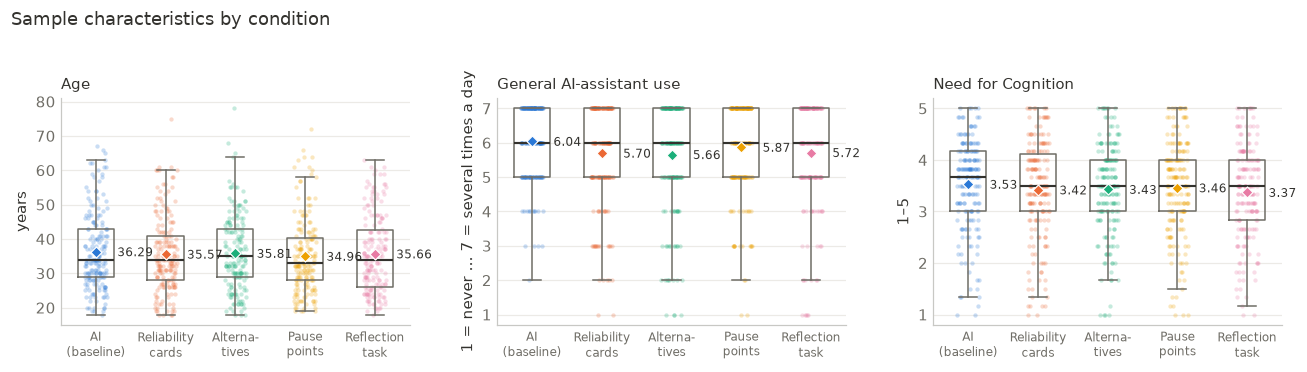

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (column, title, unit) in zip(axes, [
        ("age", "Age", "years"),
        ("ai_use_frequency", "General AI-assistant use", "1 = never … 7 = several times a day"),
        ("nfc_mean", "Need for Cognition", "1–5")]):
    condition_panel(ax, eligible, column, title, unit)
fig.suptitle("Sample characteristics by condition", x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

### B. Collection timeline and wave structure

The five conditions were not collected concurrently: `ai` and `ai-reliability` ran in July 2026
(wave 1), the three chat-structure interventions in August 2026 (wave 2), with only five extra
baseline participants collected during wave 2. Any comparison of a wave-2 intervention against
the (almost entirely wave-1) baseline is therefore **also** a comparison across recruitment
periods. Module O checks how sensitive the headline results are to this.

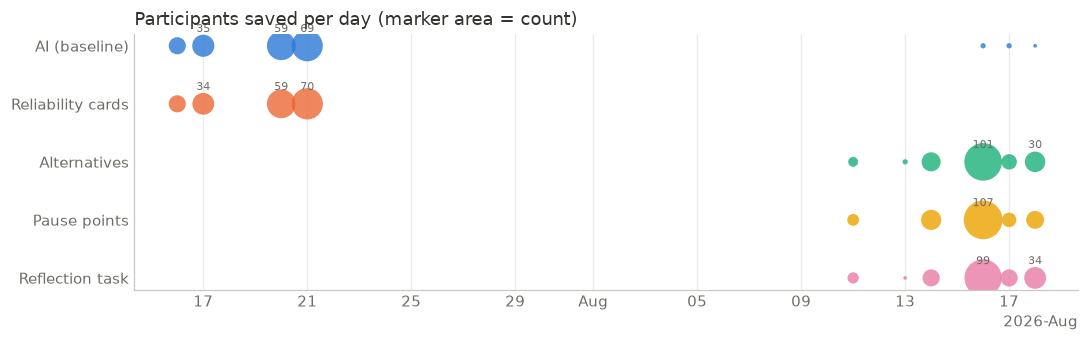

wave,wave 1,wave 2
condition,,
ai,184,5
ai-reliability,184,0
alternatives,0,183
pause-points,0,184
reflection-task,0,185


In [18]:
fig, ax = plt.subplots(figsize=(10, 3.2))
day = pd.to_datetime(participants["saved_at"], format="mixed", utc=True).dt.floor("D")
for i, condition in enumerate(CONDITIONS):
    dates = day[participants["condition"] == condition]
    counts = dates.value_counts().sort_index()
    ax.scatter(counts.index, [i] * len(counts), s=counts.to_numpy() * 6,
               color=CONDITION_COLORS[condition], alpha=0.8, linewidths=0)
    for date, count in counts.items():
        if count >= 30:
            ax.annotate(str(count), (date, i), textcoords="offset points", xytext=(0, 9),
                        ha="center", fontsize=7.5, color="#6f6d66")
ax.set_yticks(range(len(CONDITIONS)))
ax.set_yticklabels([CONDITION_LABELS[c] for c in CONDITIONS])
ax.set_title("Participants saved per day (marker area = count)", loc="left")
ax.grid(axis="y", visible=False)
ax.tick_params(length=0)
ax.invert_yaxis()
import matplotlib.dates as mdates
locator = mdates.AutoDateLocator()
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.tight_layout()
plt.show()

display(participants.pivot_table(index="condition", columns="wave", values="participant_id",
                                 aggfunc="count", fill_value=0, observed=True)
        .rename(columns=lambda w: f"wave {w}"))

### C. Primary outcomes — descriptives

The four confirmatory outcome families of the per-wave analyses, evaluated for every condition:

1. **Metacognitive accuracy** — `absolute_estimation_error` (post-study self-estimate vs actual score; lower is better)
2. **Confidence discrimination** — mean confidence on correct minus incorrect items (higher is better)
3. **Engagement** — `prompts_per_task` (interventions were expected to increase it)
4. **Performance** — `actual_score`

In [19]:
PRIMARY_OUTCOMES = [
    ("absolute_estimation_error", "Metacognitive accuracy |est − actual|", "less"),
    ("confidence_discrimination", "Confidence discrimination (pp)", "greater"),
    ("prompts_per_task", "Prompts per completed task", "greater"),
    ("actual_score", "Actual score (0–12)", "greater"),
]

descriptives = (
    eligible.groupby("condition", observed=True)[[o for o, _, _ in PRIMARY_OUTCOMES]]
    .agg(["count", "mean", "std", "median"]).round(2)
)
descriptives.columns = [f"{outcome}_{stat}" for outcome, stat in descriptives.columns]
display(descriptives.T)

condition,ai,ai-reliability,alternatives,pause-points,reflection-task
absolute_estimation_error_count,187.00,182.00,181.00,184.00,183.00
absolute_estimation_error_mean,4.42,3.35,2.96,3.61,4.03
absolute_estimation_error_std,2.42,2.23,2.01,2.45,2.48
absolute_estimation_error_median,4.00,3.00,3.00,4.00,4.00
confidence_discrimination_count,187.00,182.00,181.00,184.00,183.00
confidence_discrimination_mean,2.34,7.74,5.59,3.14,2.10
confidence_discrimination_std,8.92,12.53,13.59,11.78,9.35
confidence_discrimination_median,1.20,5.31,5.91,2.14,1.00
prompts_per_task_count,187.00,182.00,181.00,184.00,183.00
prompts_per_task_mean,1.59,1.61,1.77,3.68,2.28


### D. Primary outcomes — distributions

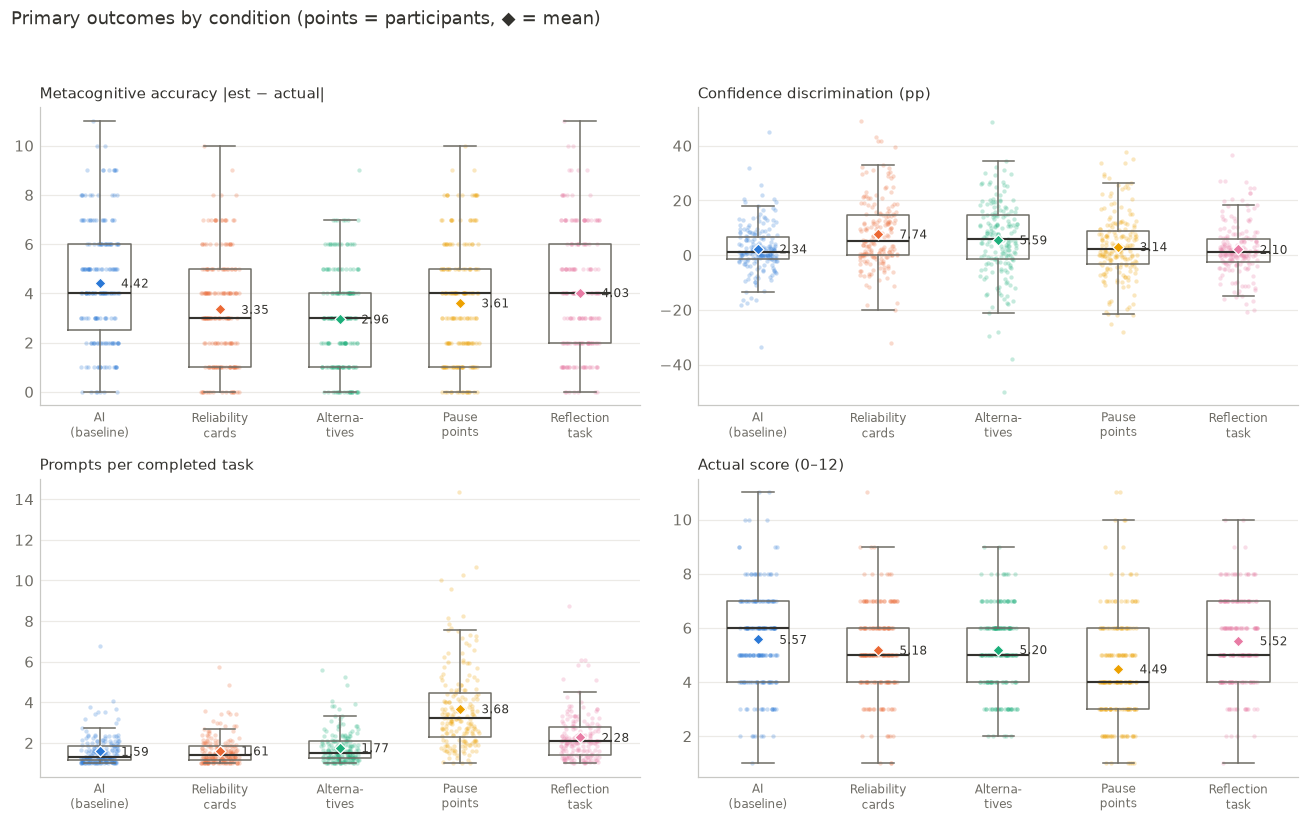

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.6))
for ax, (outcome, title, _) in zip(axes.flat, PRIMARY_OUTCOMES):
    condition_panel(ax, eligible, outcome, title)
fig.suptitle("Primary outcomes by condition (points = participants, ◆ = mean)",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

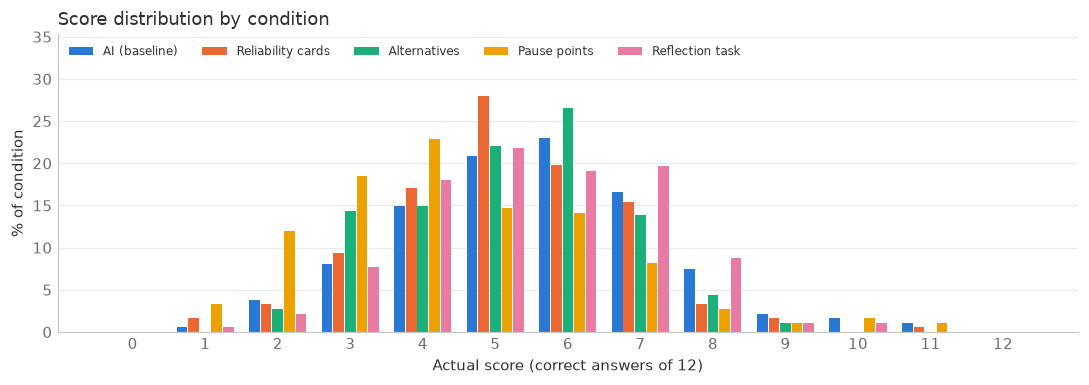

In [21]:
# Discrete score distribution: share of participants at each score level.
fig, ax = plt.subplots(figsize=(10, 3.6))
score_range = np.arange(0, 13)
width = 0.16
for i, condition in enumerate(CONDITIONS):
    scores = eligible.loc[eligible["condition"] == condition, "actual_score"]
    share = scores.value_counts(normalize=True).reindex(score_range, fill_value=0) * 100
    ax.bar(score_range + (i - 2) * width, share, width=width * 0.92,
           color=CONDITION_COLORS[condition], label=CONDITION_LABELS[condition])
ax.set_xticks(score_range)
ax.set_xlabel("Actual score (correct answers of 12)")
ax.set_ylabel("% of condition")
ax.set_title("Score distribution by condition", loc="left")
ax.set_ylim(0, ax.get_ylim()[1] * 1.2)  # headroom so the legend clears the bars
ax.legend(frameon=False, fontsize=8, ncol=5, loc="upper left")
style_ax(ax)
fig.tight_layout()
plt.show()

### E. Omnibus differences across all five conditions

Welch's ANOVA (unequal variances) and Kruskal–Wallis with ε². A significant omnibus says *some*
condition differs; module F locates the differences against the baseline.

In [22]:
omnibus = pd.DataFrame([omnibus_row(eligible, outcome) for outcome, _, _ in PRIMARY_OUTCOMES])
omnibus[["welch_F", "kruskal_H"]] = omnibus[["welch_F", "kruskal_H"]].round(2)
omnibus["epsilon_sq"] = omnibus["epsilon_sq"].round(3)
omnibus["welch_p"] = omnibus["welch_p"].map(fmt_p)
omnibus["kruskal_p"] = omnibus["kruskal_p"].map(fmt_p)
display(omnibus.style.hide(axis="index"))

outcome,welch_F,welch_df,welch_p,kruskal_H,kruskal_p,epsilon_sq
absolute_estimation_error,11.870000,"4, 455.5",< .001,38.760000,< .001,0.038000
confidence_discrimination,8.080000,"4, 452.0",< .001,33.400000,< .001,0.032000
prompts_per_task,54.060000,"4, 447.9",< .001,279.010000,< .001,0.302000
actual_score,9.440000,"4, 455.4",< .001,47.350000,< .001,0.048000


### F. Each intervention vs the AI baseline

Welch's t per intervention and outcome (directional or two-sided per `CONFIRMATORY_P_VALUE`;
the two-sided p is always reported alongside), Hedges' g with 95% CIs, and Holm correction
within each outcome family (4 comparisons).

In [23]:
pairwise_rows = []
for outcome, _, expected in PRIMARY_OUTCOMES:
    for condition in CONDITIONS:
        if condition == BASELINE:
            continue
        pairwise_rows.append(welch_vs_baseline(eligible, outcome, condition, expected))
pairwise = pd.DataFrame(pairwise_rows)
pairwise["p_holm"] = pairwise.groupby("outcome")["p"].transform(holm)
pairwise["significant"] = pairwise["p_holm"] < ALPHA

pretty = pairwise.copy()
pretty["comparison"] = pretty["condition"].map(CONDITION_LABELS) + " vs baseline"
pretty["g [CI]"] = pretty.apply(
    lambda r: f"{r.hedges_g:+.2f} [{r.g_ci_low:+.2f}, {r.g_ci_high:+.2f}]", axis=1)
pretty = pretty[["outcome", "comparison", "n", "mean", "mean_baseline", "diff",
                 "t", "df", "p", "p_two_sided", "p_holm", "g [CI]", "significant"]]
pretty[["mean", "mean_baseline", "diff", "t"]] = pretty[["mean", "mean_baseline", "diff", "t"]].round(2)
pretty["df"] = pretty["df"].round(1)
for column in ("p", "p_two_sided", "p_holm"):
    pretty[column] = pretty[column].map(fmt_p)
display(pretty.style.hide(axis="index"))

outcome,comparison,n,mean,mean_baseline,diff,t,df,p,p_two_sided,p_holm,g [CI],significant
absolute_estimation_error,Reliability cards vs baseline,182,3.350000,4.420000,-1.070000,-4.420000,365.900000,< .001,< .001,< .001,"-0.46 [-0.67, -0.25]",True
absolute_estimation_error,Alternatives vs baseline,181,2.960000,4.420000,-1.460000,-6.310000,357.500000,< .001,< .001,< .001,"-0.65 [-0.86, -0.44]",True
absolute_estimation_error,Pause points vs baseline,184,3.610000,4.420000,-0.810000,-3.200000,368.700000,< .001,= .002,= .002,"-0.33 [-0.54, -0.13]",True
absolute_estimation_error,Reflection task vs baseline,183,4.030000,4.420000,-0.390000,-1.530000,367.200000,= .064,= .127,= .064,"-0.16 [-0.36, +0.05]",False
confidence_discrimination,Reliability cards vs baseline,182,7.740000,2.340000,5.400000,4.760000,326.400000,< .001,< .001,< .001,"+0.50 [+0.29, +0.70]",True
confidence_discrimination,Alternatives vs baseline,181,5.590000,2.340000,3.250000,2.710000,309.400000,= .004,= .007,= .011,"+0.28 [+0.08, +0.49]",True
confidence_discrimination,Pause points vs baseline,184,3.140000,2.340000,0.800000,0.740000,341.000000,= .231,= .462,= .462,"+0.08 [-0.13, +0.28]",False
confidence_discrimination,Reflection task vs baseline,183,2.100000,2.340000,-0.230000,-0.250000,366.300000,= .597,= .806,= .597,"-0.03 [-0.23, +0.18]",False
prompts_per_task,Reliability cards vs baseline,182,1.610000,1.590000,0.020000,0.300000,367.000000,= .381,= .763,= .381,"+0.03 [-0.17, +0.24]",False
prompts_per_task,Alternatives vs baseline,181,1.770000,1.590000,0.180000,2.280000,358.600000,= .012,= .023,= .023,"+0.24 [+0.03, +0.44]",True


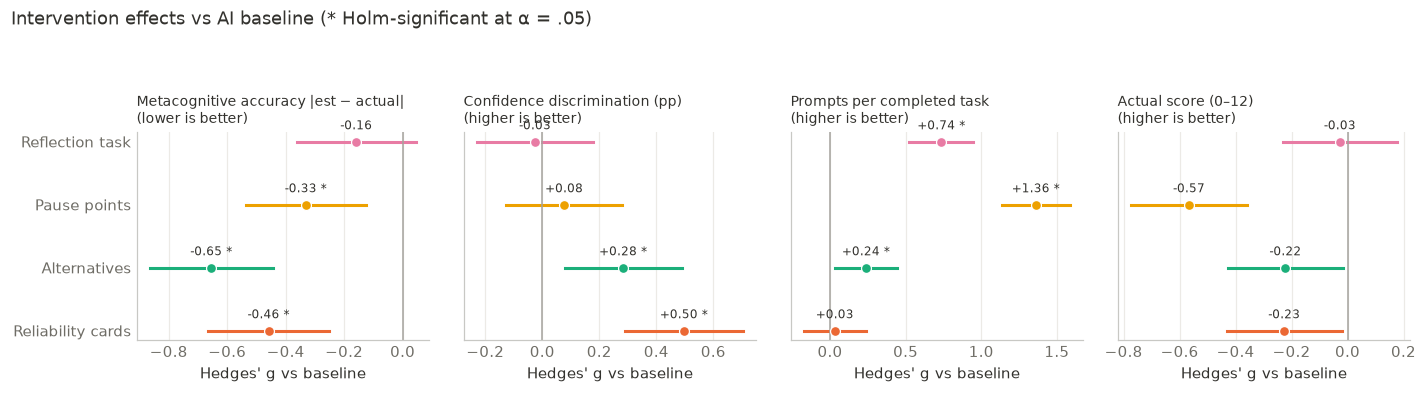

In [24]:
# Effect-size overview: Hedges' g of every intervention against the baseline.
fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
interventions = [c for c in CONDITIONS if c != BASELINE]
for ax, (outcome, title, expected) in zip(axes, PRIMARY_OUTCOMES):
    block = pairwise[pairwise["outcome"] == outcome].set_index("condition")
    for row_i, condition in enumerate(interventions):
        r = block.loc[condition]
        color = CONDITION_COLORS[condition]
        ax.plot([r["g_ci_low"], r["g_ci_high"]], [row_i, row_i], color=color, linewidth=2)
        ax.scatter([r["hedges_g"]], [row_i], color=color, s=42, zorder=3,
                   edgecolor="white", linewidth=0.8)
        marker = " *" if r["significant"] else ""
        ax.annotate(f"{r['hedges_g']:+.2f}{marker}", (r["hedges_g"], row_i),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
    ax.axvline(0, color="#a5a39d", linewidth=1)
    ax.set_yticks(range(len(interventions)))
    ax.set_yticklabels([CONDITION_LABELS[c] for c in interventions])
    better = "lower is better" if expected == "less" else "higher is better"
    ax.set_title(f"{title}\n({better})", fontsize=9, loc="left")
    ax.set_xlabel("Hedges' g vs baseline")
    ax.grid(axis="y", visible=False)
    ax.tick_params(length=0)
    ax.invert_yaxis()
fig.suptitle("Intervention effects vs AI baseline (* Holm-significant at α = .05)",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

### G. Item-level accuracy and difficulty

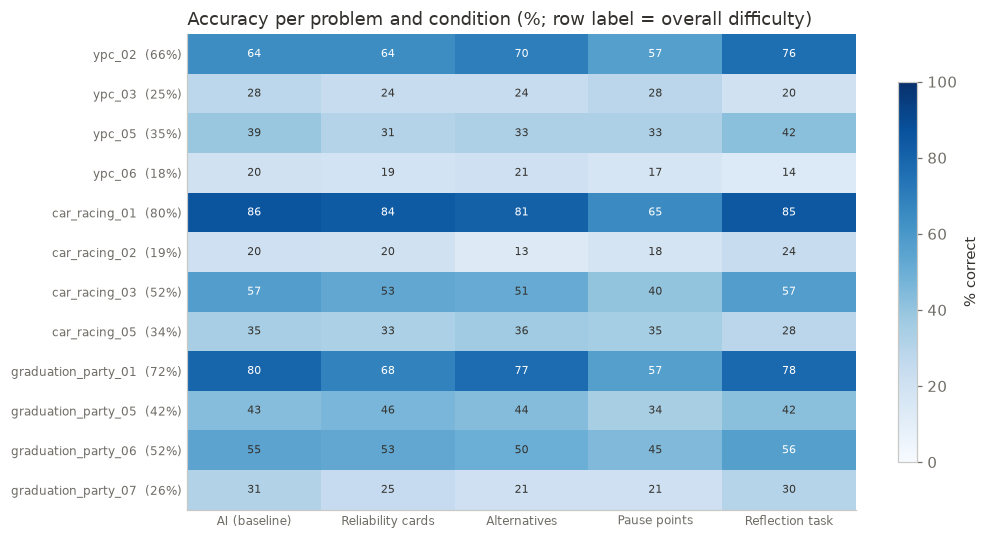

Hardest problems overall: ypc_06 (18%), car_racing_02 (19%), ypc_03 (25%)


In [25]:
item_acc = (eligible_tasks.groupby(["task_name", "condition"], observed=True)["correct"]
            .mean().unstack("condition").reindex(TASK_NAMES) * 100)
overall_difficulty = (eligible_tasks.groupby("task_name", observed=True)["correct"]
                      .mean().reindex(TASK_NAMES) * 100)

fig, ax = plt.subplots(figsize=(9.5, 5))
matrix = item_acc[CONDITIONS].to_numpy(float)
image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=100, aspect="auto")
ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([CONDITION_LABELS[c] for c in CONDITIONS], fontsize=8)
ax.set_yticks(range(len(TASK_NAMES)))
ax.set_yticklabels([f"{n}  ({d:.0f}%)" for n, d in overall_difficulty.items()], fontsize=8)
for y in range(matrix.shape[0]):
    for x in range(matrix.shape[1]):
        value = matrix[y, x]
        ax.text(x, y, f"{value:.0f}", ha="center", va="center", fontsize=7.5,
                color="white" if value > 55 else "#33322e")
ax.set_title("Accuracy per problem and condition (%; row label = overall difficulty)", loc="left")
ax.grid(visible=False)
ax.tick_params(length=0)
fig.colorbar(image, ax=ax, shrink=0.8, label="% correct")
fig.tight_layout()
plt.show()

hardest = overall_difficulty.nsmallest(3)
print("Hardest problems overall:",
      ", ".join(f"{name} ({value:.0f}%)" for name, value in hardest.items()))

### H. Confidence calibration

Left: calibration curves (item confidence bins vs share correct) per condition — the diagonal is
perfect calibration; points below it mark overconfidence. Right: the distribution of the global
signed estimation error (post-study estimate − actual score).

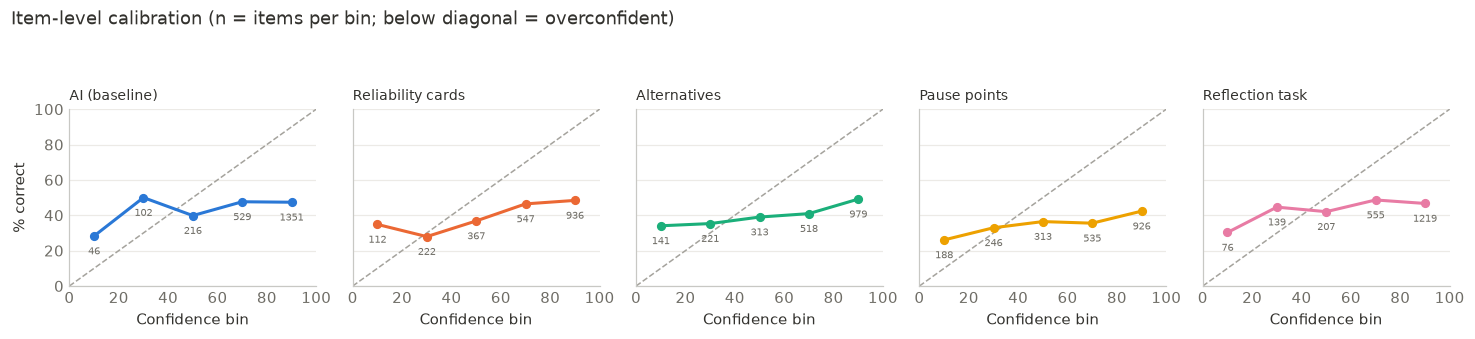

In [26]:
bins = np.array([0, 20, 40, 60, 80, 101])
bin_mids = (bins[:-1] + np.minimum(bins[1:], 100)) / 2

fig, axes = plt.subplots(1, 5, figsize=(13.5, 3.1), sharey=True)
for ax, condition in zip(axes, CONDITIONS):
    sub = eligible_tasks[(eligible_tasks["condition"] == condition)
                         & eligible_tasks["confidence"].notna()
                         & eligible_tasks["correct"].notna()]
    ax.plot([0, 100], [0, 100], color="#a5a39d", linewidth=1, linestyle="--")
    binned = sub.groupby(pd.cut(sub["confidence"], bins, right=False), observed=False)
    accuracy = binned["correct"].mean() * 100
    counts = binned["correct"].size()
    ax.plot(bin_mids, accuracy.to_numpy(float), color=CONDITION_COLORS[condition],
            linewidth=2, marker="o", markersize=5)
    for x, y, n in zip(bin_mids, accuracy.to_numpy(float), counts.to_numpy()):
        if math.isfinite(y):
            ax.annotate(f"{n}", (x, y), textcoords="offset points", xytext=(0, -12),
                        ha="center", fontsize=6.5, color="#6f6d66")
    ax.set_title(CONDITION_LABELS[condition], fontsize=9, loc="left")
    ax.set_xlabel("Confidence bin")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    style_ax(ax)
axes[0].set_ylabel("% correct")
fig.suptitle("Item-level calibration (n = items per bin; below diagonal = overconfident)",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

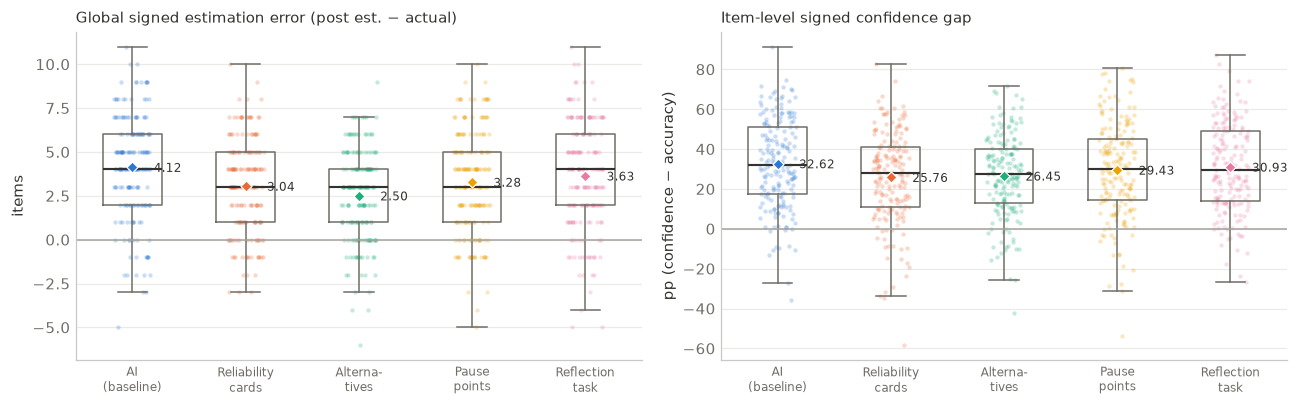

Share of participants overestimating their score: AI (baseline): 88%, Reliability cards: 80%, Alternatives: 76%, Pause points: 80%, Reflection task: 85%


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
condition_panel(axes[0], eligible, "signed_estimation_error",
                "Global signed estimation error (post est. − actual)", "items")
axes[0].axhline(0, color="#a5a39d", linewidth=1)
condition_panel(axes[1], eligible, "signed_confidence_gap",
                "Item-level signed confidence gap", "pp (confidence − accuracy)")
axes[1].axhline(0, color="#a5a39d", linewidth=1)
fig.tight_layout()
plt.show()

overconfident_share = (eligible.assign(over=eligible["signed_estimation_error"] > 0)
                       .groupby("condition", observed=True)["over"].mean() * 100)
print("Share of participants overestimating their score:",
      ", ".join(f"{CONDITION_LABELS[c]}: {v:.0f}%" for c, v in overconfident_share.items()))

### I. Global self-estimates: pre vs post

Participants estimated — before and after the main block — how many of the 12 problems they
would solve **with the AI**, **without the AI**, and how many the **AI alone** would solve.
Open markers = pre, filled = post; the diamond in the left panel is the condition's mean actual
score, i.e. where a perfectly calibrated post estimate should land.

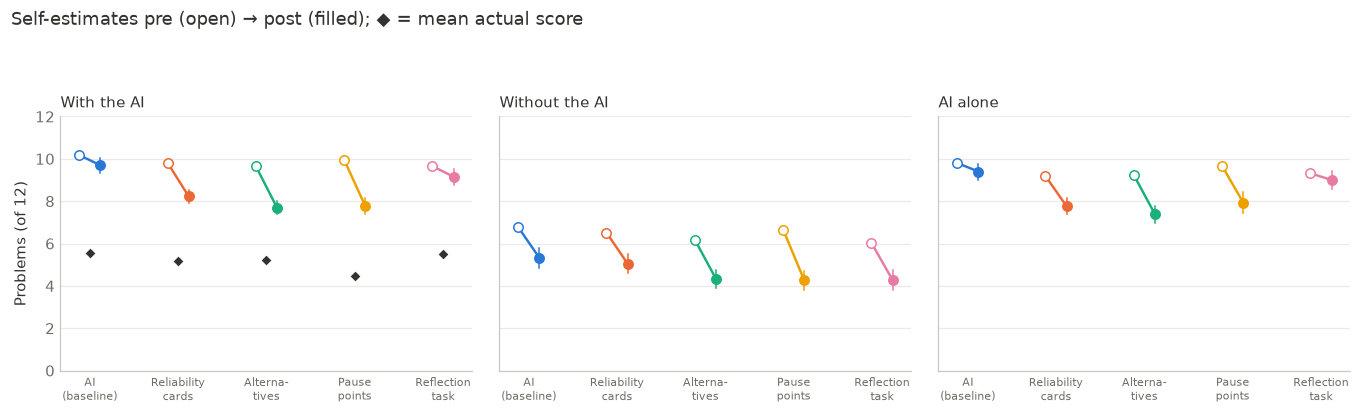

In [28]:
ESTIMATE_PAIRS = [
    ("pre_with_ai", "post_with_ai", "With the AI"),
    ("pre_without_ai", "post_without_ai", "Without the AI"),
    ("pre_ai_alone", "post_ai_alone", "AI alone"),
]

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8), sharey=True)
for ax, (pre_col, post_col, title) in zip(axes, ESTIMATE_PAIRS):
    for i, condition in enumerate(CONDITIONS):
        sub = eligible[eligible["condition"] == condition]
        color = CONDITION_COLORS[condition]
        pre_mean, *_ = mean_ci(sub[pre_col].to_numpy(float))
        post_mean, post_low, post_high = mean_ci(sub[post_col].to_numpy(float))
        ax.plot([i - 0.12, i + 0.12], [pre_mean, post_mean], color=color, linewidth=1.6)
        ax.scatter([i - 0.12], [pre_mean], facecolor="white", edgecolor=color, s=38, zorder=3)
        ax.scatter([i + 0.12], [post_mean], color=color, s=38, zorder=3)
        ax.plot([i + 0.12, i + 0.12], [post_low, post_high], color=color, linewidth=1)
        if pre_col == "pre_with_ai":
            actual = sub["actual_score"].mean()
            ax.scatter([i], [actual], marker="D", s=30, facecolor="#33322e",
                       edgecolor="white", zorder=4)
    ax.set_xticks(range(len(CONDITIONS)))
    ax.set_xticklabels([TICK_LABELS[c] for c in CONDITIONS], fontsize=7.5)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_ylim(0, 12)
    style_ax(ax)
axes[0].set_ylabel("Problems (of 12)")
fig.suptitle("Self-estimates pre (open) → post (filled); ◆ = mean actual score",
             x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

In [29]:
shift_rows = []
for shift_col, label in [("estimate_shift_with_ai", "with AI"),
                         ("estimate_shift_without_ai", "without AI"),
                         ("estimate_shift_ai_alone", "AI alone")]:
    for condition in CONDITIONS:
        values = eligible.loc[eligible["condition"] == condition, shift_col].dropna()
        t_stat, p = stats.ttest_1samp(values, 0)
        shift_rows.append({"estimate": label, "condition": CONDITION_LABELS[condition],
                           "n": len(values), "mean_shift": round(values.mean(), 2),
                           "t": round(t_stat, 2), "p": fmt_p(p)})
print("Post − pre estimate shifts (one-sample t vs 0; exploratory):")
display(pd.DataFrame(shift_rows).style.hide(axis="index"))

Post − pre estimate shifts (one-sample t vs 0; exploratory):


estimate,condition,n,mean_shift,t,p
with AI,AI (baseline),187,-0.480000,-2.630000,= .009
with AI,Reliability cards,182,-1.590000,-8.060000,< .001
with AI,Alternatives,179,-1.940000,-10.190000,< .001
with AI,Pause points,183,-2.180000,-10.830000,< .001
with AI,Reflection task,182,-0.510000,-2.520000,= .012
without AI,AI (baseline),187,-1.450000,-7.940000,< .001
without AI,Reliability cards,182,-1.470000,-7.060000,< .001
without AI,Alternatives,179,-1.840000,-9.030000,< .001
without AI,Pause points,183,-2.390000,-12.000000,< .001
without AI,Reflection task,182,-1.780000,-8.290000,< .001


### J. Chat behavior and time investment

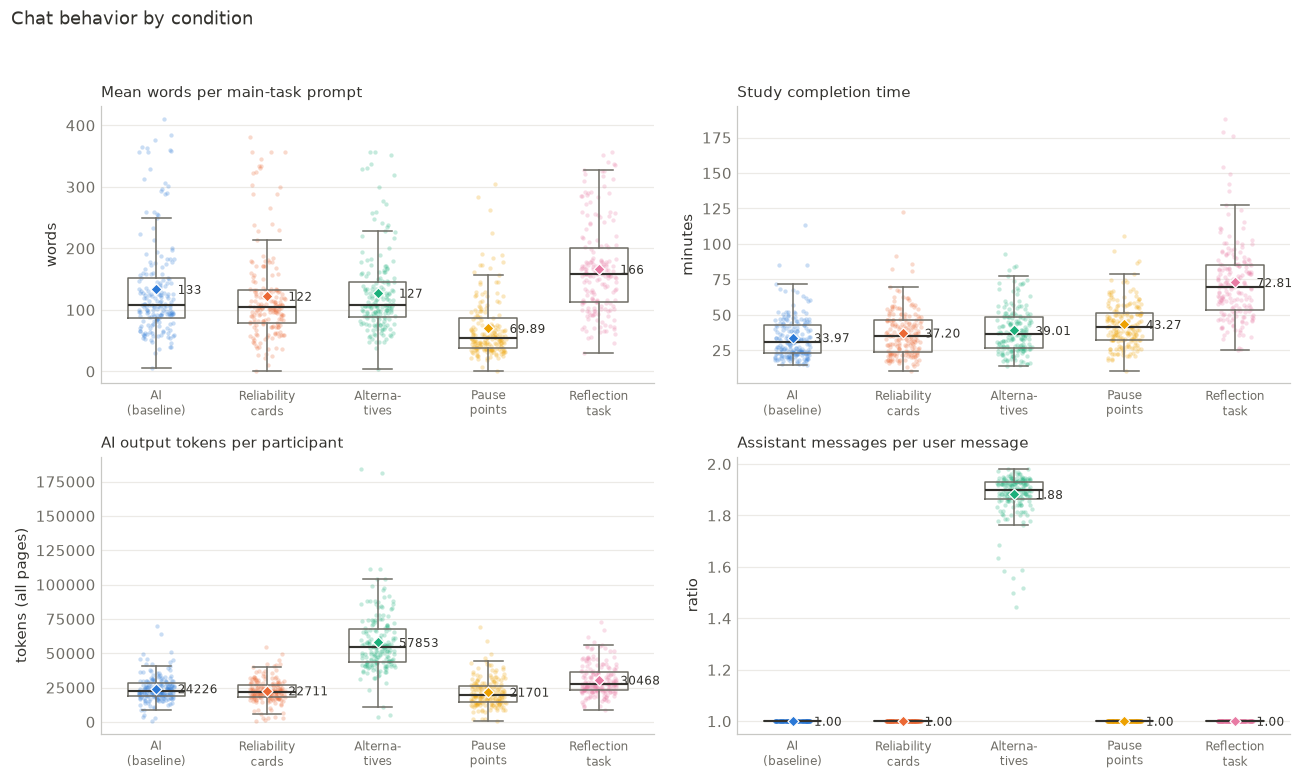

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.2))
condition_panel(axes[0, 0], eligible, "mean_prompt_words",
                "Mean words per main-task prompt", "words")
condition_panel(axes[0, 1], eligible, "completion_minutes",
                "Study completion time", "minutes")
# Every analyzed participant prompted the AI on all 12 problems
# (main_tasks_prompted = 12 throughout), so AI output volume is the more
# informative engagement panel: the alternatives condition generates two
# replies per prompt, which roughly doubles the tokens produced.
condition_panel(axes[1, 0], eligible, "assistant_output_tokens",
                "AI output tokens per participant", "tokens (all pages)")
# Assistant replies per user prompt: the alternatives condition answers each
# prompt with two parallel replies, pause-points splits one answer into steps.
ratio = eligible["total_assistant_messages"] / eligible["total_user_messages"].replace(0, np.nan)
condition_panel(axes[1, 1], eligible.assign(msg_ratio=ratio), "msg_ratio",
                "Assistant messages per user message", "ratio")
fig.suptitle("Chat behavior by condition", x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

In [31]:
dwell = (eligible_tasks.groupby("condition", observed=True)["dwell_seconds"]
         .agg(["count", "median", "mean"]).round(1)
         .rename(columns={"count": "task_pages", "median": "median_s", "mean": "mean_s"}))
dwell["median_min"] = (dwell["median_s"] / 60).round(2)
print("Dwell time per main problem page (page-entry to next page-entry):")
display(dwell)

behavior = eligible.groupby("condition", observed=True).agg(
    prompts_per_task=("prompts_per_task", "mean"),
    prompt_words=("mean_prompt_words", "mean"),
    pasted_task_share=("pasted_task_share", "mean"),
    chat_resets_total=("chat_resets", "sum"),
    assistant_output_tokens=("assistant_output_tokens", "mean"),
).round(2)
display(behavior)
print("pasted_task_share exists only on wave-2 records: n =",
      eligible.groupby("condition", observed=True)["pasted_task_share"].count().to_dict())

Dwell time per main problem page (page-entry to next page-entry):


,task_pages,median_s,mean_s,median_min
condition,,,,
ai,2244,71.2,101.8,1.19
ai-reliability,2184,81.6,115.2,1.36
alternatives,2172,91.8,128.0,1.53
pause-points,2208,118.0,150.4,1.97
reflection-task,2196,122.6,157.3,2.04


,prompts_per_task,prompt_words,pasted_task_share,chat_resets_total,assistant_output_tokens
condition,,,,,
ai,1.59,133.33,0.84,9,24226.16
ai-reliability,1.61,122.22,NaN,0,22710.85
alternatives,1.77,127.20,0.81,187,57853.46
pause-points,3.68,69.89,0.72,192,21700.54
reflection-task,2.28,165.97,0.70,235,30468.11


pasted_task_share exists only on wave-2 records: n = {'ai': 5, 'ai-reliability': 0, 'alternatives': 181, 'pause-points': 184, 'reflection-task': 183}


### K. Intervention exposure and manipulation checks

Did participants actually receive each intervention as designed?

* **Reliability cards** should appear on all 12 problems (`ai-reliability`).
* The **intervention gate** (wave 2) tests whether the participant's prompt covers the task
  text before the structured reply is triggered; `gate_matched` counts passes.
* **Reflection pages** (reflection-task) should be answered after every problem.

In [32]:
reliability_sub = eligible[eligible["condition"] == "ai-reliability"]
full_exposure = (reliability_sub["reliability_cards_presented"] >= 12).mean() * 100
print(f"ai-reliability: cards on all 12 problems for {full_exposure:.0f}% of participants "
      f"(median {reliability_sub['reliability_cards_presented'].median():.0f}/12, "
      f"mean similarity tests {reliability_sub['similarity_tests'].mean():.1f}, "
      f"cards hidden by {100 * (reliability_sub['cards_hidden'] > 0).mean():.0f}%)")

reflection_sub = eligible[eligible["condition"] == "reflection-task"]
print(f"reflection-task: median {reflection_sub['reflection_pages_answered'].median():.0f}/12 "
      f"reflection pages answered, median {reflection_sub['reflection_words'].median():.0f} words total")

exposure = eligible.groupby("condition", observed=True).agg(
    gate_tests=("gate_tests", "mean"),
    gate_matched=("gate_matched", "mean"),
    gate_max_coverage=("gate_max_coverage", "mean"),
    cards_presented=("reliability_cards_presented", "mean"),
    reflection_pages=("reflection_pages_answered", "mean"),
    reflection_words=("reflection_words", "mean"),
).round(2)
display(exposure)

ai-reliability: cards on all 12 problems for 90% of participants (median 12/12, mean similarity tests 21.7, cards hidden by 72%)
reflection-task: median 12/12 reflection pages answered, median 973 words total


,gate_tests,gate_matched,gate_max_coverage,cards_presented,reflection_pages,reflection_words
condition,,,,,,
ai,0.45,0.32,1.00,0.00,0.0,0.00
ai-reliability,0.00,0.00,NaN,11.69,0.0,0.00
alternatives,17.76,11.14,0.99,0.00,0.0,0.00
pause-points,20.70,8.89,0.97,0.00,0.0,0.00
reflection-task,22.30,11.07,0.99,0.00,12.0,1117.85


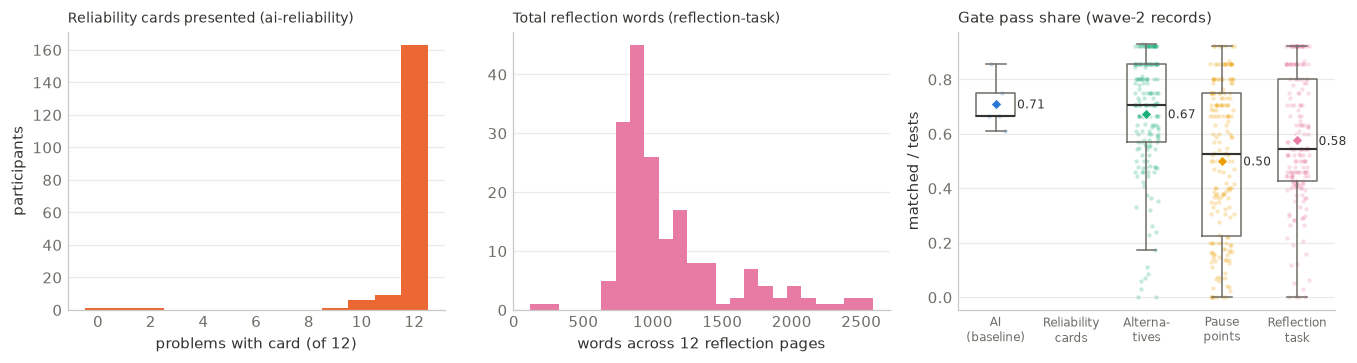

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].hist(reliability_sub["reliability_cards_presented"], bins=np.arange(-0.5, 13.5),
             color=CONDITION_COLORS["ai-reliability"])
axes[0].set_title("Reliability cards presented (ai-reliability)", fontsize=9, loc="left")
axes[0].set_xlabel("problems with card (of 12)")
axes[0].set_ylabel("participants")
axes[1].hist(reflection_sub["reflection_words"], bins=24,
             color=CONDITION_COLORS["reflection-task"])
axes[1].set_title("Total reflection words (reflection-task)", fontsize=9, loc="left")
axes[1].set_xlabel("words across 12 reflection pages")
wave2 = eligible[eligible["wave"] == 2]
gate_share = (wave2["gate_matched"] / wave2["gate_tests"].replace(0, np.nan)).rename("share")
condition_panel(axes[2], wave2.assign(gate_pass_share=gate_share), "gate_pass_share",
                "Gate pass share (wave-2 records)", "matched / tests")
for ax in axes[:2]:
    style_ax(ax)
fig.tight_layout()
plt.show()

### L. Standardized questionnaires: SUS, UEQ-S, NASA-TLX, NFC, Trust

In [34]:
def scale_item_matrix(scale_key: str) -> pd.DataFrame:
    """Per-participant scored items (collected in Part 1, Section 7)."""
    keep = set(eligible["participant_id"])
    rows = {entry["participant_id"]: entry[scale_key] for entry in scale_items_store
            if entry["participant_id"] in keep and entry["run_index"] == 0 and entry[scale_key]}
    if not rows:
        return pd.DataFrame()
    width = max(len(v) for v in rows.values())
    return pd.DataFrame.from_dict(
        {pid: list(v) + [math.nan] * (width - len(v)) for pid, v in rows.items()}, orient="index")


SCALES = [
    ("sus_score", "sus", "SUS (0–100)"),
    ("ueq_overall", "ueq", "UEQ-S overall (−3…+3)"),
    ("tlx_mean", "tlx", "NASA-TLX (0–20)"),
    ("nfc_mean", "nfc", "NFC (1–5)"),
    ("trust_mean", "trust", "Trust (1–5)"),
]

scale_summary = eligible.groupby("condition", observed=True)[
    [c for c, _, _ in SCALES]].agg(["mean", "std"]).round(2)
display(scale_summary)

alphas = {label: round(float(cronbach_alpha(scale_item_matrix(key))), 2)
          for _, key, label in SCALES}
print("Cronbach's α (scored items, analysis sample):", alphas)

sus_score        ueq_overall       tlx_mean       nfc_mean  \
                     mean    std        mean   std     mean   std     mean   
condition                                                                    
ai                  79.51  18.11        1.31  1.11     7.67  3.28     3.53   
ai-reliability      74.56  18.13        1.07  1.08     9.22  2.89     3.42   
alternatives        67.46  18.74        0.80  1.00     9.52  2.86     3.43   
pause-points        59.86  22.38        0.21  1.28     9.67  2.85     3.46   
reflection-task     72.77  17.78        0.86  1.17    11.68  3.36     3.37   

                      trust_mean        
                  std       mean   std  
condition                               
ai               0.88       3.78  0.76  
ai-reliability   0.96       3.45  0.77  
alternatives     0.90       3.15  0.81  
pause-points     0.93       3.26  0.81  
reflection-task  0.92       3.64  0.78

Cronbach's α (scored items, analysis sample): {'SUS (0–100)': 0.89, 'UEQ-S overall (−3…+3)': 0.89, 'NASA-TLX (0–20)': 0.69, 'NFC (1–5)': 0.89, 'Trust (1–5)': 0.88}


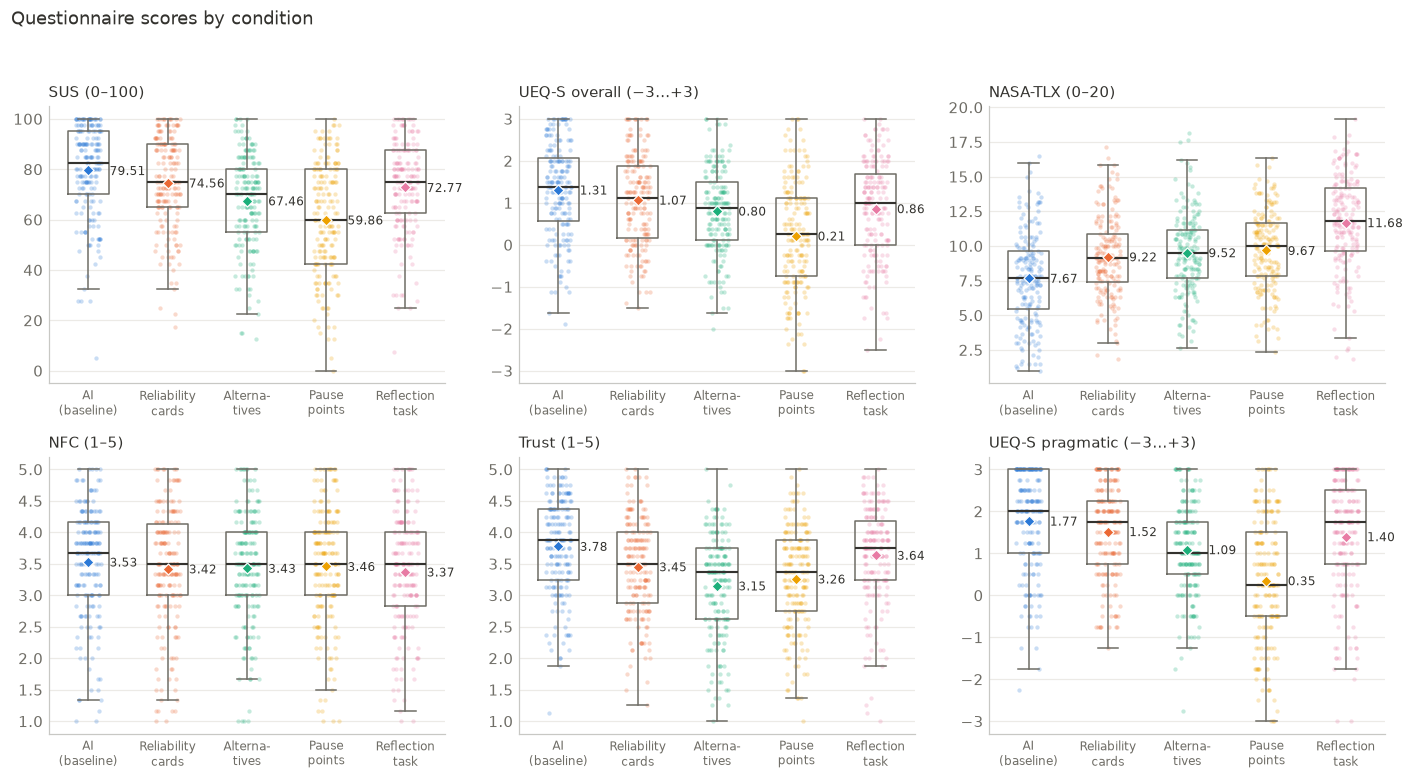

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2))
panels = SCALES + [("ueq_pragmatic", None, "UEQ-S pragmatic (−3…+3)")]
for ax, (column, _, label) in zip(axes.flat, panels):
    condition_panel(ax, eligible, column, label)
fig.suptitle("Questionnaire scores by condition", x=0.01, ha="left", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

In [36]:
scale_tests = []
for column, _, label in SCALES:
    for condition in CONDITIONS:
        if condition == BASELINE:
            continue
        x = eligible.loc[eligible["condition"] == condition, column].dropna().to_numpy(float)
        y = eligible.loc[eligible["condition"] == BASELINE, column].dropna().to_numpy(float)
        test = stats.ttest_ind(x, y, equal_var=False)
        g, g_low, g_high = hedges_g(x, y)
        scale_tests.append({"scale": label, "condition": CONDITION_LABELS[condition],
                            "diff": round(x.mean() - y.mean(), 2), "p_two_sided": test.pvalue,
                            "hedges_g": round(g, 2)})
scale_tests = pd.DataFrame(scale_tests)
scale_tests["p_holm"] = scale_tests.groupby("scale")["p_two_sided"].transform(holm)
scale_tests["significant"] = scale_tests["p_holm"] < ALPHA
scale_tests["p_two_sided"] = scale_tests["p_two_sided"].map(fmt_p)
scale_tests["p_holm"] = scale_tests["p_holm"].map(fmt_p)
print("Exploratory two-sided Welch tests vs baseline, Holm-corrected within scale:")
display(scale_tests.style.hide(axis="index"))

Exploratory two-sided Welch tests vs baseline, Holm-corrected within scale:


scale,condition,diff,p_two_sided,hedges_g,p_holm,significant
SUS (0–100),Reliability cards,-4.940000,= .009,-0.270000,= .009,True
SUS (0–100),Alternatives,-12.050000,< .001,-0.650000,< .001,True
SUS (0–100),Pause points,-19.640000,< .001,-0.960000,< .001,True
SUS (0–100),Reflection task,-6.730000,< .001,-0.370000,< .001,True
UEQ-S overall (−3…+3),Reliability cards,-0.240000,= .035,-0.220000,= .035,True
UEQ-S overall (−3…+3),Alternatives,-0.500000,< .001,-0.470000,< .001,True
UEQ-S overall (−3…+3),Pause points,-1.090000,< .001,-0.910000,< .001,True
UEQ-S overall (−3…+3),Reflection task,-0.440000,< .001,-0.390000,< .001,True
NASA-TLX (0–20),Reliability cards,1.550000,< .001,0.500000,< .001,True
NASA-TLX (0–20),Alternatives,1.840000,< .001,0.600000,< .001,True


### M. Intervention-experience items (post questionnaire)

Each condition answered its own block of Likert items about the intervention it saw, plus the
shared item *“I usually double-checked AI-generated answers before relying on them.”* (1–5).
The shared item is comparable across conditions; the block items describe each intervention on
its own terms.

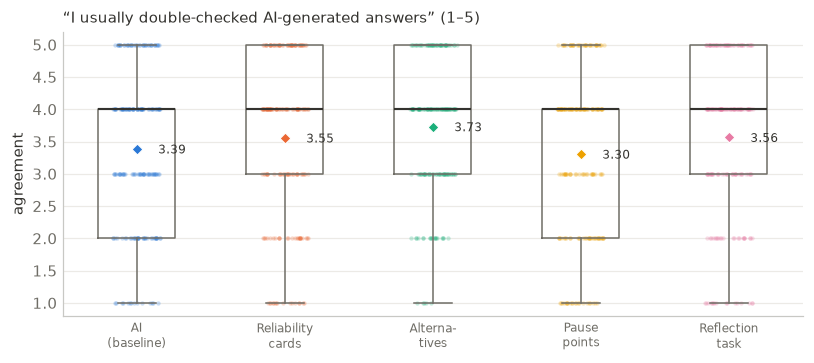

condition,question,count,mean,std
ai,I usually double-checked AI-generated answers before relying on them.,187,3.390000,1.230000
ai-reliability,I paid attention to the evaluation strategies within the reliability information.,182,3.640000,1.160000
ai-reliability,I paid attention to the reliability information.,182,4.070000,1.010000
ai-reliability,I usually double-checked AI-generated answers before relying on them.,182,3.550000,1.270000
ai-reliability,The reliability information helped me evaluate the AI’s answer more carefully.,182,3.960000,1.060000
ai-reliability,The reliability information made me less likely to accept the AI’s answer without checking it.,182,3.580000,1.260000
ai-reliability,The reliability information shown in this study changed how I interacted with the AI.,182,3.640000,1.270000
alternatives,I usually double-checked AI-generated answers before relying on them.,181,3.730000,1.050000
alternatives,The multiple alternatives reply helped me evaluate the AI’s answer more carefully.,181,4.090000,1.000000
alternatives,The multiple alternatives reply shown in this study changed how I interacted with the AI.,181,3.880000,1.110000


In [37]:
fig, ax = plt.subplots(figsize=(7.5, 3.4))
condition_panel(ax, eligible, "double_checked_answers",
                "“I usually double-checked AI-generated answers” (1–5)", "agreement")
fig.tight_layout()
plt.show()

experience_rows = []
keep = set(eligible["participant_id"])
for rec in records:
    if str(rec["participantId"]) not in keep or rec["_run_index"] > 0:
        continue
    _, postq_task = find_task(rec, r"usually double-checked AI-generated answers")
    for r in responses(postq_task or {}):
        question = re.sub(r"\s+", " ", str(r.get("question") or "")).strip()
        value = number(r.get("answer"))
        if question and math.isfinite(value):
            experience_rows.append({"condition": rec["condition"],
                                    "question": question, "value": value})
experience = (pd.DataFrame(experience_rows)
              .groupby(["condition", "question"], observed=True)["value"]
              .agg(["count", "mean", "std"]).round(2).reset_index())
experience = experience[experience["count"] >= 10]
with pd.option_context("display.max_colwidth", 95):
    display(experience.style.hide(axis="index"))

### N. Exploratory moderators

OLS with treatment-coded condition (baseline = `ai`) × a standardized moderator. Interactions
ask whether an intervention works differently for e.g. high-NFC participants. All exploratory.

In [38]:
import statsmodels.formula.api as smf

model_frame = eligible.assign(condition_str=eligible["condition"].astype(str)).copy()
for source, z_name in [("nfc_mean", "nfc_z"), ("trust_mean", "trust_z"),
                       ("ai_use_frequency", "ai_use_z")]:
    values = model_frame[source]
    model_frame[z_name] = (values - values.mean()) / values.std()

MODERATOR_MODELS = [
    ("actual_score", "nfc_z", "Need for Cognition"),
    ("confidence_discrimination", "trust_z", "Trust in the AI"),
    ("absolute_estimation_error", "ai_use_z", "General AI-use frequency"),
]

interaction_rows = []
for outcome, moderator, moderator_label in MODERATOR_MODELS:
    formula = (f"{outcome} ~ C(condition_str, Treatment(reference='ai')) * {moderator}")
    fit = smf.ols(formula, data=model_frame).fit()
    for term, coef in fit.params.items():
        if ":" in term or term == moderator:
            match = re.search(r"T\.([\w-]+)", term)
            interaction_rows.append({
                "outcome": outcome, "moderator": moderator_label,
                "term": (f"{match.group(1)} × {moderator_label}" if match and ":" in term
                         else f"{moderator_label} (baseline slope)"),
                "coef": round(coef, 3), "p": fmt_p(fit.pvalues[term]),
            })
    print(f"{outcome} ~ condition × {moderator_label}: "
          f"R² = {fit.rsquared:.3f}, n = {int(fit.nobs)}")
display(pd.DataFrame(interaction_rows).style.hide(axis="index"))

actual_score ~ condition × Need for Cognition: R² = 0.055, n = 917
confidence_discrimination ~ condition × Trust in the AI: R² = 0.044, n = 917
absolute_estimation_error ~ condition × General AI-use frequency: R² = 0.058, n = 917


outcome,moderator,term,coef,p
actual_score,Need for Cognition,Need for Cognition (baseline slope),-0.193000,= .145
actual_score,Need for Cognition,ai-reliability × Need for Cognition,0.258000,= .155
actual_score,Need for Cognition,alternatives × Need for Cognition,0.241000,= .197
actual_score,Need for Cognition,pause-points × Need for Cognition,0.417000,= .023
actual_score,Need for Cognition,reflection-task × Need for Cognition,0.050000,= .785
confidence_discrimination,Trust in the AI,Trust in the AI (baseline slope),-1.185000,= .186
confidence_discrimination,Trust in the AI,ai-reliability × Trust in the AI,0.785000,= .535
confidence_discrimination,Trust in the AI,alternatives × Trust in the AI,2.948000,= .017
confidence_discrimination,Trust in the AI,pause-points × Trust in the AI,0.061000,= .961
confidence_discrimination,Trust in the AI,reflection-task × Trust in the AI,1.990000,= .114


### O. Wave sensitivity checks

The baseline is 97% wave 1 while three interventions are wave 2 (module B). Two checks:

1. **Wave-1-only baseline** — re-estimate every intervention effect with the five wave-2
   baseline participants removed. Effects that move materially would signal cohort sensitivity.
2. **Within-wave-2 omnibus** — compare the three wave-2 interventions among themselves,
   a comparison free of any cross-wave confound.

In [39]:
baseline_w1 = eligible[(eligible["condition"] != BASELINE) | (eligible["wave"] == 1)]
sensitivity = []
for outcome, _, expected in PRIMARY_OUTCOMES:
    for condition in CONDITIONS:
        if condition == BASELINE:
            continue
        full = pairwise.set_index(["outcome", "condition"]).loc[(outcome, condition)]
        redone = welch_vs_baseline(baseline_w1, outcome, condition, expected)
        sensitivity.append({
            "outcome": outcome, "condition": CONDITION_LABELS[condition],
            "g_full": round(full["hedges_g"], 2), "g_wave1_baseline": round(redone["hedges_g"], 2),
            "delta_g": round(redone["hedges_g"] - full["hedges_g"], 2),
        })
sensitivity = pd.DataFrame(sensitivity)
print(f"max |Δg| across all comparisons: {sensitivity['delta_g'].abs().max():.2f}")
display(sensitivity.style.hide(axis="index"))

max |Δg| across all comparisons: 0.02


outcome,condition,g_full,g_wave1_baseline,delta_g
absolute_estimation_error,Reliability cards,-0.460000,-0.480000,-0.020000
absolute_estimation_error,Alternatives,-0.650000,-0.680000,-0.020000
absolute_estimation_error,Pause points,-0.330000,-0.350000,-0.020000
absolute_estimation_error,Reflection task,-0.160000,-0.180000,-0.020000
confidence_discrimination,Reliability cards,0.500000,0.500000,0.000000
confidence_discrimination,Alternatives,0.280000,0.290000,0.000000
confidence_discrimination,Pause points,0.080000,0.080000,0.000000
confidence_discrimination,Reflection task,-0.030000,-0.020000,0.010000
prompts_per_task,Reliability cards,0.030000,0.030000,0.000000
prompts_per_task,Alternatives,0.240000,0.240000,0.000000


In [40]:
wave2_only = eligible[eligible["condition"].isin(["alternatives", "pause-points", "reflection-task"])]
wave2_rows = []
for outcome, _, _ in PRIMARY_OUTCOMES:
    groups = {c: wave2_only.loc[wave2_only["condition"] == c, outcome].dropna().to_numpy(float)
              for c in ["alternatives", "pause-points", "reflection-task"]}
    welch = welch_anova(groups)
    kw_h, kw_p = stats.kruskal(*groups.values())
    wave2_rows.append({"outcome": outcome, "welch_F": round(welch["F"], 2),
                       "welch_p": fmt_p(welch["p"]), "kruskal_p": fmt_p(kw_p)})
print("Omnibus among the three wave-2 interventions only (no cross-wave confound):")
display(pd.DataFrame(wave2_rows).style.hide(axis="index"))

ai_by_wave = (eligible[eligible["condition"] == BASELINE]
              .groupby("wave")[["actual_score", "mean_confidence", "prompts_per_task"]]
              .agg(["count", "mean"]).round(2))
print("Baseline participants by wave (wave 2 n is tiny — descriptive only):")
display(ai_by_wave)

Omnibus among the three wave-2 interventions only (no cross-wave confound):


outcome,welch_F,welch_p,kruskal_p
absolute_estimation_error,10.810000,< .001,< .001
confidence_discrimination,4.060000,= .018,= .001
prompts_per_task,72.320000,< .001,< .001
actual_score,14.790000,< .001,< .001


Baseline participants by wave (wave 2 n is tiny — descriptive only):


actual_score       mean_confidence        prompts_per_task      
            count  mean           count   mean            count  mean
wave                                                                 
1             182  5.58             182  79.20              182  1.59
2               5  5.20               5  73.95                5  1.68

### P. Compact results summary

In [41]:
lines = [f"Analysis sample: {len(eligible)} participants "
         f"(exclusions applied: {APPLY_EXCLUSIONS}; p-values: {CONFIRMATORY_P_VALUE}).\n"]
for outcome, title, expected in PRIMARY_OUTCOMES:
    block = pairwise[pairwise["outcome"] == outcome]
    base_mean = block["mean_baseline"].iloc[0]
    lines.append(f"{title} — baseline mean {base_mean:.2f}:")
    for _, r in block.iterrows():
        flag = "SIGNIFICANT" if r["significant"] else "n.s."
        direction = "better" if ((r["diff"] < 0) == (expected == "less")) else "worse"
        note = ""
        if direction == "worse" and not r["significant"] and r["p_two_sided"] < ALPHA:
            note = f" [opposite direction, two-sided p {fmt_p(r['p_two_sided'])}]"
        lines.append(f"  {CONDITION_LABELS[r['condition']]:<18} mean {r['mean']:.2f} "
                     f"({r['diff']:+.2f}, {direction} than baseline), "
                     f"g = {r['hedges_g']:+.2f}, Holm p {fmt_p(r['p_holm'])} -> {flag}{note}")
    lines.append("")
lines.append("Caveats: cross-wave cohort confound for the three wave-2 interventions "
             "(see modules B and O); analyses derive from the JSON records (the convenience "
             "CSVs are answerResults-sourced since Aug 2026 and verified consistent in "
             "Section 4); directional tests follow the per-wave preregistrations.")
print("\n".join(lines))

Analysis sample: 917 participants (exclusions applied: True; p-values: directional).

Metacognitive accuracy |est − actual| — baseline mean 4.42:
  Reliability cards  mean 3.35 (-1.07, better than baseline), g = -0.46, Holm p < .001 -> SIGNIFICANT
  Alternatives       mean 2.96 (-1.46, better than baseline), g = -0.65, Holm p < .001 -> SIGNIFICANT
  Pause points       mean 3.61 (-0.81, better than baseline), g = -0.33, Holm p = .002 -> SIGNIFICANT
  Reflection task    mean 4.03 (-0.39, better than baseline), g = -0.16, Holm p = .064 -> n.s.

Confidence discrimination (pp) — baseline mean 2.34:
  Reliability cards  mean 7.74 (+5.40, better than baseline), g = +0.50, Holm p < .001 -> SIGNIFICANT
  Alternatives       mean 5.59 (+3.25, better than baseline), g = +0.28, Holm p = .011 -> SIGNIFICANT
  Pause points       mean 3.14 (+0.80, better than baseline), g = +0.08, Holm p = .462 -> n.s.
  Reflection task    mean 2.10 (-0.23, worse than baseline), g = -0.03, Holm p = .597 -> n.s.

Promp

### Q. Export prepared tables

Writes analysis-ready tables to `notebook_analysis_output/` (not version-controlled), including
the open-text answers for qualitative coding.

In [42]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

participants.drop(columns=["saved_ts"]).to_csv(OUTPUT_DIR / "participant_metrics.csv", index=False)
task_level.to_csv(OUTPUT_DIR / "task_metrics.csv", index=False)
prompts.to_csv(OUTPUT_DIR / "prompts.csv", index=False)
pairwise.to_csv(OUTPUT_DIR / "pairwise_vs_baseline.csv", index=False)
pd.DataFrame([omnibus_row(eligible, outcome) for outcome, _, _ in PRIMARY_OUTCOMES]) \
    .to_csv(OUTPUT_DIR / "omnibus_tests.csv", index=False)
funnel.to_csv(OUTPUT_DIR / "exclusion_funnel.csv")

open_rows = []
keep = set(eligible["participant_id"])
for rec in records:
    if str(rec["participantId"]) not in keep or rec["_run_index"] > 0:
        continue
    _, postq_task = find_task(rec, r"usually double-checked AI-generated answers")
    for r in responses(postq_task or {}):
        answer = str(r.get("answer") or "").strip()
        if answer and not math.isfinite(number(answer)):
            open_rows.append({"participant_id": rec["participantId"],
                              "condition": rec["condition"],
                              "question": re.sub(r"\s+", " ", str(r.get("question") or "")).strip(),
                              "answer": answer})
pd.DataFrame(open_rows).to_csv(OUTPUT_DIR / "open_text_answers.csv", index=False)

for path in sorted(OUTPUT_DIR.iterdir()):
    print(f"{path}  ({path.stat().st_size / 1e3:.0f} kB)")

notebook_analysis_output/exclusion_funnel.csv  (0 kB)
notebook_analysis_output/omnibus_tests.csv  (1 kB)
notebook_analysis_output/open_text_answers.csv  (453 kB)
notebook_analysis_output/pairwise_condition_tests.csv  (33 kB)
notebook_analysis_output/pairwise_vs_baseline.csv  (4 kB)
notebook_analysis_output/participant_metrics.csv  (570 kB)
notebook_analysis_output/prompts.csv  (1548 kB)
notebook_analysis_output/r_confirmatory_vs_baseline.csv  (4 kB)
notebook_analysis_output/r_effect_sizes_vs_baseline.png  (82 kB)
notebook_analysis_output/r_hypothesis_verdicts.csv  (1 kB)
notebook_analysis_output/r_pairwise_tests.csv  (8 kB)
notebook_analysis_output/rahnev_measures_accuracy_adjusted.csv  (1 kB)
notebook_analysis_output/rahnev_measures_condition_tests.csv  (2 kB)
notebook_analysis_output/rahnev_measures_per_participant.csv  (101 kB)
notebook_analysis_output/task_metrics.csv  (2013 kB)
